<a href="https://colab.research.google.com/github/Rakhayeva/Data-Science-Projects-in-English/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Industry: Steel Production

**Project Description**

The "Steel Bird" metallurgical plant aims to optimize production costs by reducing electricity consumption during the steel processing stage in the ladle furnace. A key factor in achieving this goal is the precise control and prediction of the molten steel temperature at the end of the technological cycle.

This project focuses on developing a machine learning model capable of forecasting the final steel temperature based on process parameters (electrode heating, addition of alloying materials, gas purging, and intermediate temperature measurements). The customer will use this model to simulate the process and identify opportunities for energy consumption optimization.

**Project Goal**

Build a machine learning model that predicts the final steel temperature after the ladle processing stage with high accuracy. This model will be used for process simulation and energy cost optimization.
- **Target Metric** (Test Set): $MAE \le 6$.
- **Additional Requirement**: Calculate and interpret the $R^2$ metric for the best model on the test set.

**Research Workflow**
- [Data Loading and Initial Analysis](#Loading)
- [Exploratory Data Analysis (EDA) and Preprocessing](#EDA)
- [Data Merging](#Merging)
- [Feature Engineering](#Engineering)
- [EDA and Preprocessing of the Merged Dataset](#Merged)
- [Data Preparation for Modeling](#Modeling)
- [Model Training and Hyperparameter Tuning](#Training)
- [Model Evaluation and Selection](#Evaluation)
- [Feature Importance Analysis](#Importance)
- [Conclusions and Recommendations](#Recommendations)

## Data Description

The dataset consists of several files obtained from various sources:
- `data_arc_new.csv` — Electrode heating data;
- `data_bulk_new.csv` — Bulk material supply data (volume);
- `data_bulk_time_new.csv` — Bulk material supply data (time);
- `data_gas_new.csv` — Gas purging data;
- `data_temp_new.csv` — Temperature measurement results;
- `data_wire_new.csv` — Wire material data (volume);
- `data_wire_time_new.csv` — Wire material data (time).

## <a name='Loading'></a> Data Loading

### Library import

In [1]:
import os
import time
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from functools import reduce
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Constants:

In [2]:
RANDOM_STATE = 70425

In [3]:
# Record the start time for the loading process
start_time = time.time()

# List of files and their corresponding dataframe names
files = {
    'data_arc': 'data_arc_new.csv',
    'data_bulk': 'data_bulk_new.csv',
    'data_bulk_time': 'data_bulk_time_new.csv',
    'data_gas': 'data_gas_new.csv',
    'data_temp': 'data_temp_new.csv',
    'data_wire': 'data_wire_new.csv',
    'data_wire_time': 'data_wire_time_new.csv'
}

# Define the path to the Google Drive folder
path = '/content/drive/MyDrive/Yandex_Practicum/datasets for DS/'

# Load all tables through a loop
for name, filename in files.items():
    full_path = os.path.join(path, filename)
    try:
        # Load the CSV file into a global variable with the specified name
        globals()[name] = pd.read_csv(full_path)
        print(f"Successfully loaded: {name}")
    except FileNotFoundError:
        print(f"Error: The file {filename} was not found at {path}")

Successfully loaded: data_arc
Successfully loaded: data_bulk
Successfully loaded: data_bulk_time
Successfully loaded: data_gas
Successfully loaded: data_temp
Successfully loaded: data_wire
Successfully loaded: data_wire_time


## Functions

In [4]:
def boxplot(df, column):
    """Generates a boxplot for a specified column."""
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[column], color='lightblue')
    plt.title('Boxplot')
    plt.xlabel(column)
    plt.show()

def hist(df, column, bins):
    """Generates a histogram with a KDE plot for a specified column."""
    plt.figure(figsize=(8, 6))
    sns.histplot(x=df[column], kde=True, color='lightblue', bins=bins)
    plt.title('Histogram')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

def plot_distribution(df, column, bins):
    """Generates both a boxplot and a histogram side-by-side for distribution analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Boxplot
    sns.boxplot(x=df[column], ax=axes[0], color='lightblue')
    axes[0].set_title('Boxplot')
    axes[0].set_xlabel(column)

    # Histogram
    sns.histplot(x=df[column], kde=True, bins=bins, color='lightblue', ax=axes[1])
    axes[1].set_title('Histogram')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

def plot_weekly_counts_single(data, column):
    """Plots the frequency of additions for a specific material on a weekly basis."""
    # Create timestamps for a single material (Bulk/Wire)
    melted_data = data.melt(id_vars=[], value_vars=[column], var_name=column, value_name='datetime')

    # Remove rows with missing datetime values
    melted_data = melted_data.dropna(subset=['datetime'])

    # Ensure data type is datetime
    melted_data['datetime'] = pd.to_datetime(melted_data['datetime'], errors='coerce')

    # Drop NaT rows after conversion
    melted_data = melted_data.dropna(subset=['datetime'])

    # Create a week column (convert datetime to period)
    melted_data['week'] = melted_data['datetime'].dt.to_period('W')

    # Convert period to string for seaborn compatibility
    melted_data['week'] = melted_data['week'].astype(str)

    # Count the number of entries for each week
    weekly_counts = melted_data.groupby(['week', column]).size().reset_index(name='count')

    # Build the plot
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='week', y='count', hue=column, data=weekly_counts, marker='o')

    plt.xticks(rotation=45)
    plt.title(f'Weekly Addition Frequency for {column}')
    plt.xlabel('Week')
    plt.ylabel('Count of Additions')
    plt.tight_layout()
    plt.show()

## <a name='EDA'></a> Exploratory Data Analysis (EDA) and Preprocessing

### Electrode Data

In [5]:
data_arc.info()
display(data_arc.head(5))
display(data_arc.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


- No missing values were found.
- The columns Arc heating start and Arc heating end are currently represented as object types, even though they contain date and time information. We will convert them to `datetime64[ns]` using pd.to_datetime.
- In the Reactive power column, there is a minimum value of -715. Given that the median is 0.441639, this extreme negative value is likely a measurement error or a technical anomaly.
- We need to rename the columns to English and apply snake_case formatting for better accessibility and coding standards.

In [6]:
# Dictionary for column renaming
translation_dict = {
    'Начало нагрева дугой': 'arc_heating_start',
    'Конец нагрева дугой': 'arc_heating_end',
    'Активная мощность': 'active_power',
    'Реактивная мощность': 'reactive_power'
}

# Rename columns to English snake_case
data_arc = data_arc.rename(columns=translation_dict)

# Convert data types to datetime
data_arc['arc_heating_start'] = pd.to_datetime(data_arc['arc_heating_start'])
data_arc['arc_heating_end'] = pd.to_datetime(data_arc['arc_heating_end'])

# Set 'key' as the index
data_arc = data_arc.set_index('key')

# Verification of changes
data_arc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14876 entries, 1 to 3241
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   arc_heating_start  14876 non-null  datetime64[ns]
 1   arc_heating_end    14876 non-null  datetime64[ns]
 2   active_power       14876 non-null  float64       
 3   reactive_power     14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 581.1 KB


#### Distribution Analysis

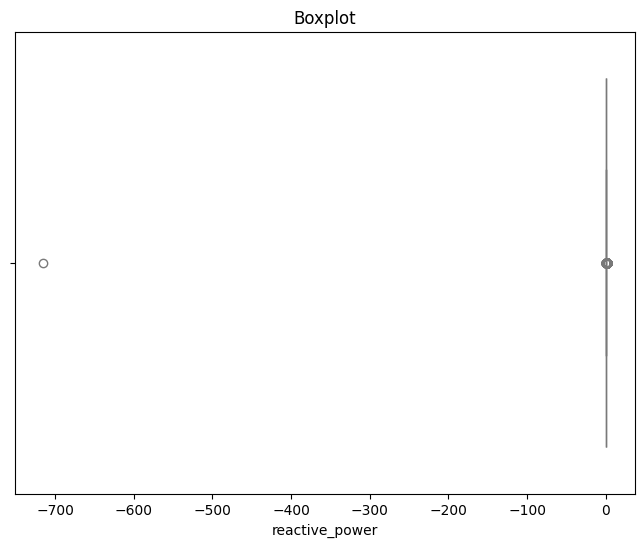

In [7]:
# Let's look at the distribution using a boxplot
boxplot(data_arc, 'reactive_power')

Indeed, this is a data error. We can't delete it, as we'll lose an entire arc heating iteration. Let's see which batch had -715.

In [8]:
# Checking for a batch with a negative value
data_arc[data_arc['reactive_power'] == -715.479924]

,arc_heating_start,arc_heating_end,active_power,reactive_power
key,,,,
2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


In [9]:
# Anomaly can be removed
data_arc = data_arc[data_arc['reactive_power'] != -715.479924]

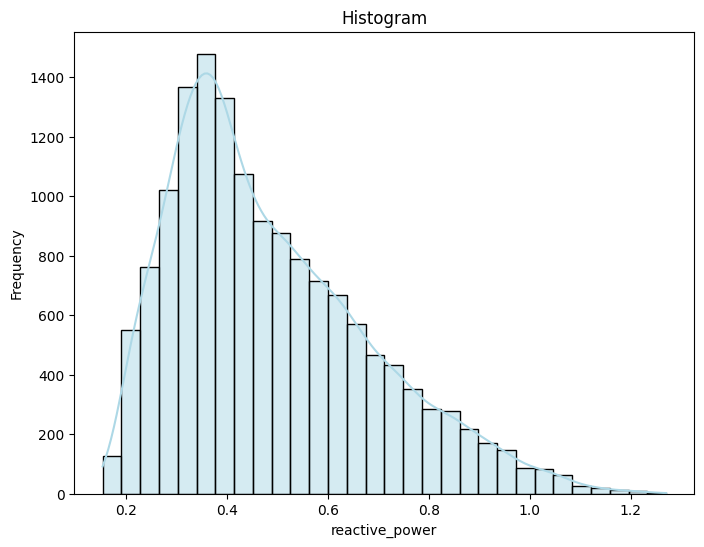

In [10]:
# Check the distribution on the histogram
hist(data_arc, 'reactive_power', 30)

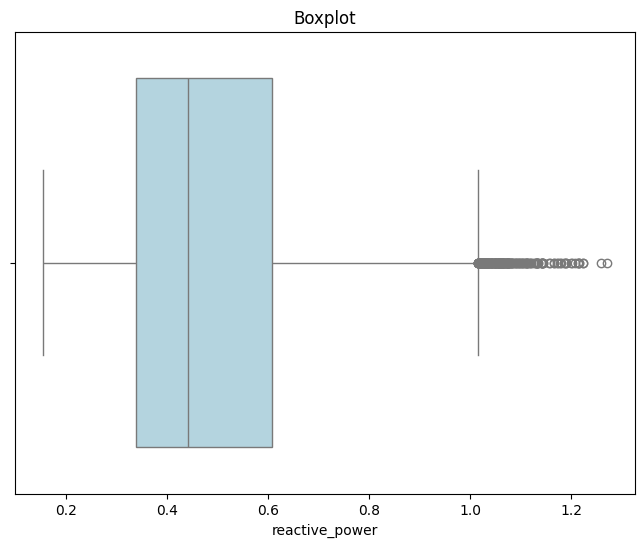

In [11]:
# Check the distribution on the boxplot
boxplot(data_arc, 'reactive_power')

The distribution for reactive_power is right-skewed, with a peak at approximately 0.35 and a median of 0.45, indicating that in most cases, reactive power remains at a low level. Outliers are present in the sample.

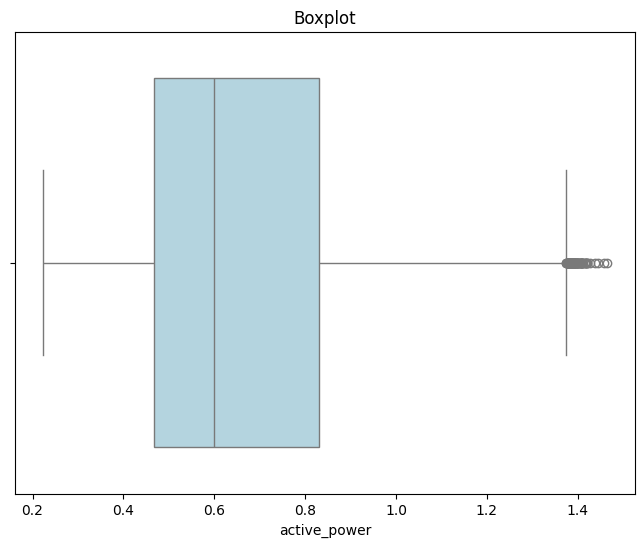

In [12]:
# Check the distribution of Active Power using a boxplot
boxplot(data_arc, 'active_power')

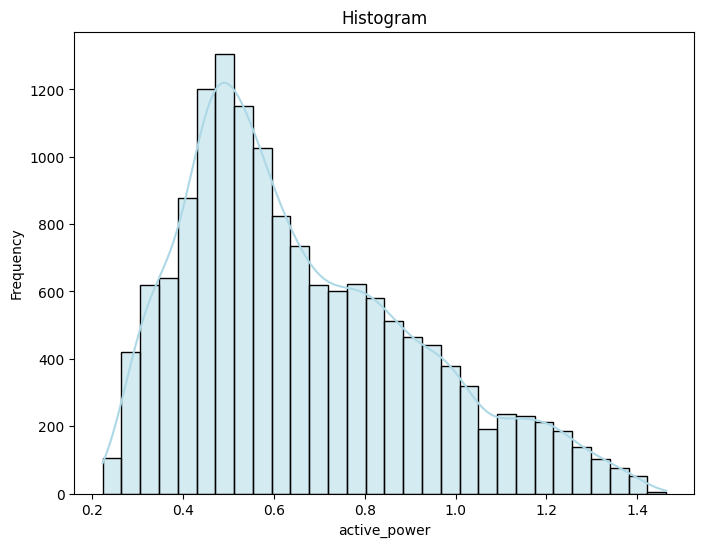

In [13]:
# Check the distribution on a histogram
hist(data_arc, 'active_power', 30)

The distribution is right-skewed, meaning most batches operate with low active power (around 0.5), while a few batches with significantly higher power pull the tail of the distribution to the right. Outliers are also present here.

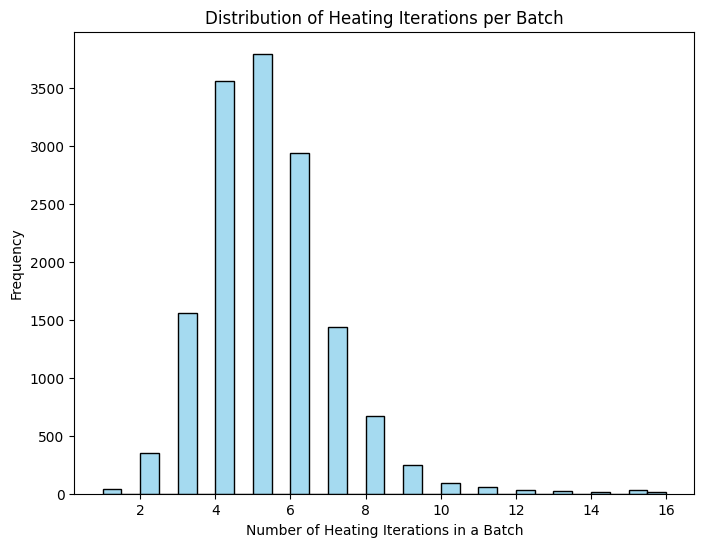

In [14]:
# Calculate the number of heating iterations for each batch and visualize the distribution
iteration_num_arc = data_arc.groupby('key')['active_power'].transform('count')

# Plotting the histogram for iterations
plt.figure(figsize=(8, 6))
sns.histplot(iteration_num_arc, bins=30, kde=False, color='skyblue')
plt.title('Distribution of Heating Iterations per Batch')
plt.xlabel('Number of Heating Iterations in a Batch')
plt.ylabel('Frequency')
plt.show()

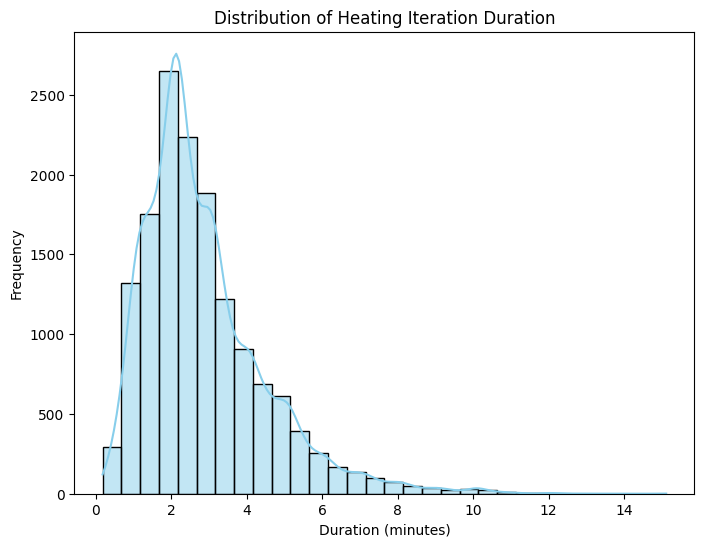

In [15]:
# Analyze the duration of each individual heating iteration
time_per_iter_arc = (data_arc['arc_heating_end'] - data_arc['arc_heating_start']).dt.total_seconds() / 60

plt.figure(figsize=(8, 6))
sns.histplot(time_per_iter_arc, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Heating Iteration Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

Most batches undergo 4 iterations, with an average heating duration of approximately 2 minutes per iteration.

### Bulk Material Supply Data

#### Volume of Supplied Materials

In [16]:
data_bulk.info()
display(data_bulk.head(5))
display(data_bulk.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


- Columns `Bulk 1` to `Bulk 15` (volume of material supplied) contain many missing values. The customer clarified that missing values indicate the material was not added for those specific batches, meaning the volume is zero.
- Data types are correct for the analysis.
- Parameter names need to be converted to snake_case.

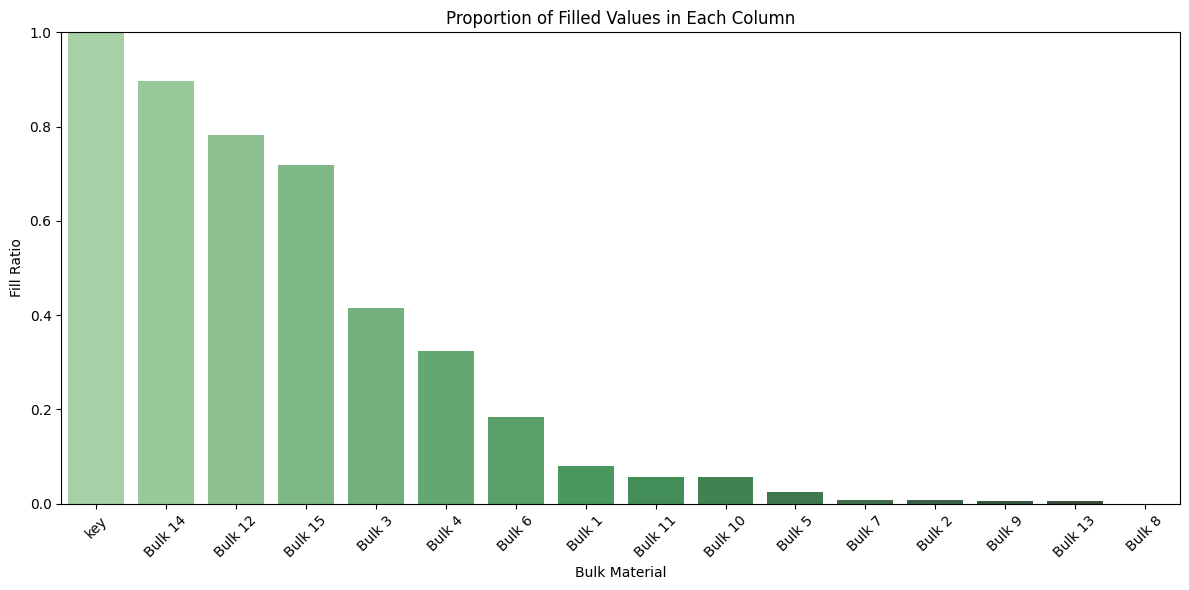

In [17]:
# Calculate the proportion of filled (non-null) values
filled_ratio = (data_bulk.notna().sum() / len(data_bulk)).sort_values(ascending=False)

# Visualize the fill ratio
plt.figure(figsize=(12, 6))
sns.barplot(x=filled_ratio.index, y=filled_ratio.values, palette='Greens_d')
plt.xticks(rotation=45)
plt.title('Proportion of Filled Values in Each Column')
plt.ylabel('Fill Ratio')
plt.xlabel('Bulk Material')
plt.ylim(0, 1)  # Set limit from 0 to 1 for clarity
plt.tight_layout()
plt.show()

Bulk materials 6, 1, 11, 10, 5, 7, 2, 9, 13, and 8 are used in less than 20% of the batches. We will remove these columns because the model may not have enough information to learn their impact effectively, and they are unlikely to improve overall predictive performance.

In [18]:
# Check feature count before dropping
print("Shape before dropping low-usage features:", data_bulk.shape)

# Drop columns with a fill rate below 20%
data_bulk = data_bulk.drop(columns=filled_ratio[filled_ratio < 0.2].index)

# Check feature count after dropping
print("Shape after dropping:", data_bulk.shape)
display(data_bulk.head(5))

Shape before dropping low-usage features: (3129, 16)
Shape after dropping: (3129, 6)


,key,Bulk 3,Bulk 4,Bulk 12,Bulk 14,Bulk 15
0,1,NaN,43.0,206.0,150.0,154.0
1,2,NaN,73.0,206.0,149.0,154.0
2,3,NaN,34.0,205.0,152.0,153.0
3,4,NaN,81.0,207.0,153.0,154.0
4,5,NaN,78.0,203.0,151.0,152.0


In [19]:
# Dictionary for column renaming
translation_dict = {
    'Bulk 3': 'bulk_3',
    'Bulk 4': 'bulk_4',
    'Bulk 12': 'bulk_12',
    'Bulk 14': 'bulk_14',
    'Bulk 15': 'bulk_15'
}

# Rename columns to snake_case
data_bulk = data_bulk.rename(columns=translation_dict)

# Verify the changes and data types
data_bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_3   1298 non-null   float64
 2   bulk_4   1014 non-null   float64
 3   bulk_12  2450 non-null   float64
 4   bulk_14  2806 non-null   float64
 5   bulk_15  2248 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 146.8 KB


In [20]:
# Fill missing values with 0 (as per the business logic)
data_bulk = data_bulk.fillna(0)

# Verify that no missing values remain
print("Remaining missing values:\n", data_bulk.isna().sum())

Remaining missing values:
 key        0
bulk_3     0
bulk_4     0
bulk_12    0
bulk_14    0
bulk_15    0
dtype: int64


In [21]:
# Set 'key' as the index
data_bulk = data_bulk.set_index('key')
display(data_bulk.head(5))

,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15
key,,,,,
1,0.0,43.0,206.0,150.0,154.0
2,0.0,73.0,206.0,149.0,154.0
3,0.0,34.0,205.0,152.0,153.0
4,0.0,81.0,207.0,153.0,154.0
5,0.0,78.0,203.0,151.0,152.0


#### Distribution Analysis

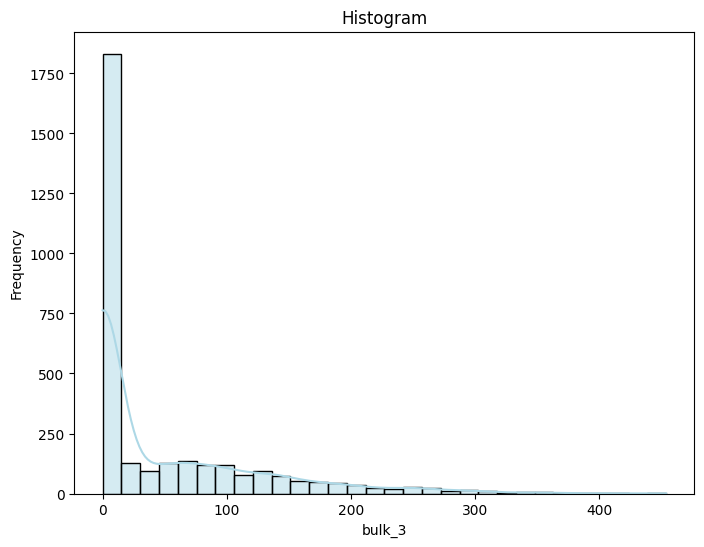

In [22]:
# Check the distribution using histograms for each bulk material
hist(data_bulk, 'bulk_3', 30)

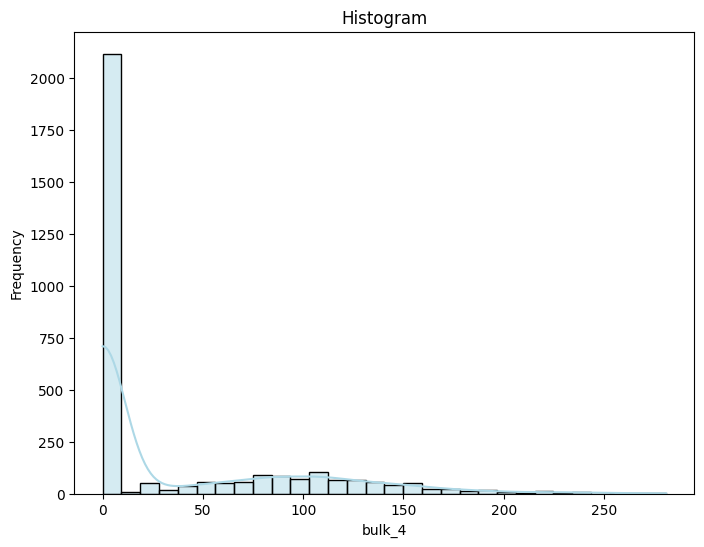

In [23]:
hist(data_bulk, 'bulk_4', 30)

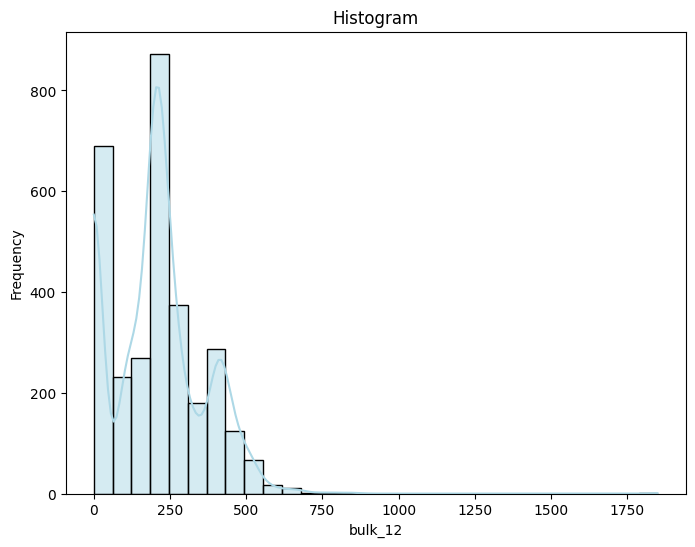

In [24]:
hist(data_bulk, 'bulk_12', 30)

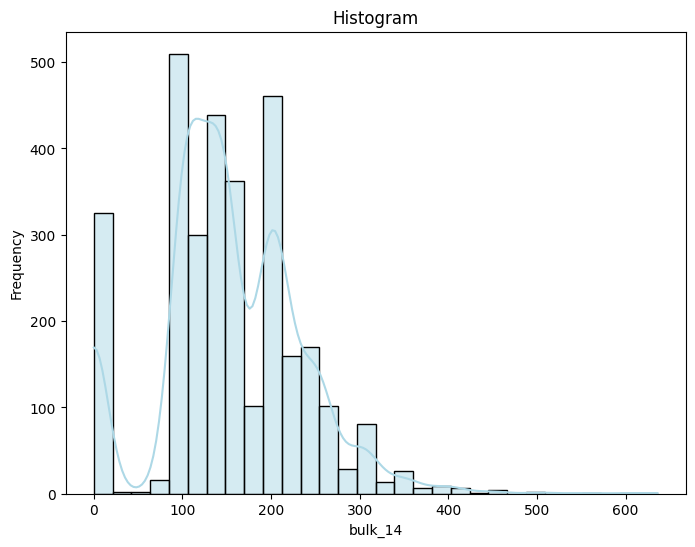

In [25]:
hist(data_bulk, 'bulk_14', 30)

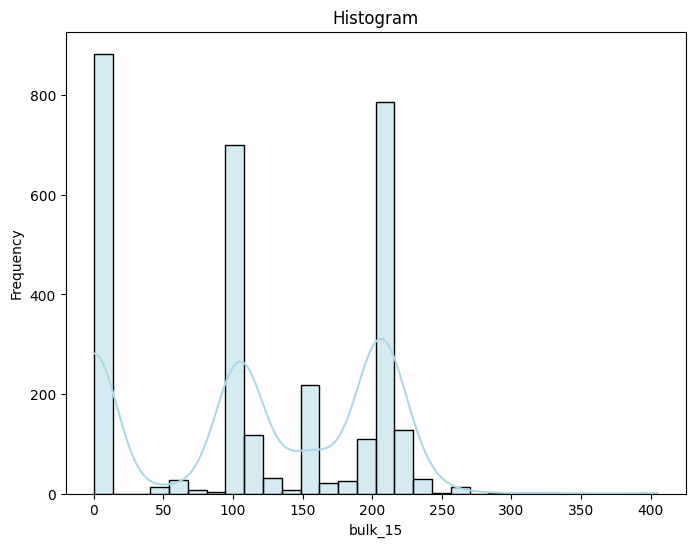

In [26]:
hist(data_bulk, 'bulk_15', 30)

- Bulk 3: Typically added in small volumes, generally up to 16.
- Bulk 4: Also added in small volumes, reaching up to 10.
- Bulk 12: Added in significantly larger quantities—mostly up to 500—with noticeable peaks at values of 60 and 250.
- Bulk 14: Mostly added in volumes up to 280, with specific peaks at 20, 100, 150, and 200.
- Bulk 15: Added in volumes up to 220, with peaks observed at 15, 100, 150, and 220.

#### Correlation Analysis

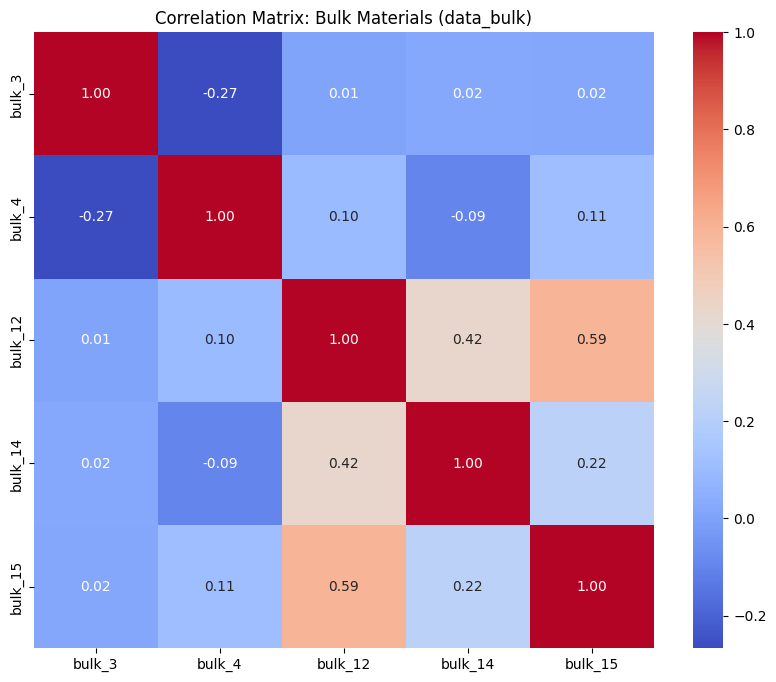

In [27]:
# Calculate and visualize the correlation between bulk parameters
plt.figure(figsize=(10, 8))
sns.heatmap(data_bulk.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Bulk Materials (data_bulk)')
plt.show()

- A correlation of **0.59** between `Bulk 12` and `Bulk 15` indicates a moderate positive relationship. This suggests that when the supply of `Bulk 12` increases, the supply of `Bulk 15` also tends to increase, and vice-versa.
- A correlation of **0.42** between `Bulk 12` and `Bulk 14` shows a weak-to-moderate positive relationship. This indicates a general tendency to supply these materials together or within a similar operational mode.

### Material Supply Time

In [28]:
data_bulk_time.info()
display(data_bulk_time.head(5))
display(data_bulk_time.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaN,NaN,NaN,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:58:00,NaN,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,2019-05-03 13:34:12,2019-05-03 13:30:47


,key
count,3129.000000
mean,1624.383509
std,933.337642
min,1.000000
25%,816.000000
50%,1622.000000
75%,2431.000000
max,3241.000000


The structures of the `data_bulk` and `data_bulk_time` tables are identical. To ensure consistency for future analysis, we need to convert the timestamp columns to the `datetime64[ns]` format and set the batch key as the index.

In [29]:
# Filter the parameters to match the columns retained in data_bulk
data_bulk_time = data_bulk_time[['key', 'Bulk 3', 'Bulk 4', 'Bulk 12', 'Bulk 14', 'Bulk 15']]
columns_to_convert = ['Bulk 3', 'Bulk 4', 'Bulk 12', 'Bulk 14', 'Bulk 15']

# Convert the data to datetime format for each column
for column in columns_to_convert:
    data_bulk_time[column] = pd.to_datetime(data_bulk_time[column], errors='coerce')

# Set 'key' as the index
data_bulk_time = data_bulk_time.set_index('key')

# Verification of data types and structure
print(data_bulk_time.info())
display(data_bulk_time.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Bulk 3   1298 non-null   datetime64[ns]
 1   Bulk 4   1014 non-null   datetime64[ns]
 2   Bulk 12  2450 non-null   datetime64[ns]
 3   Bulk 14  2806 non-null   datetime64[ns]
 4   Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 146.7 KB
None


,Bulk 3,Bulk 4,Bulk 12,Bulk 14,Bulk 15
key,,,,,
1,NaT,2019-05-03 11:28:48,2019-05-03 11:24:31,2019-05-03 11:14:50,2019-05-03 11:10:43
2,NaT,2019-05-03 11:36:50,2019-05-03 11:53:30,2019-05-03 11:48:37,2019-05-03 11:44:39
3,NaT,2019-05-03 12:32:39,2019-05-03 12:27:13,2019-05-03 12:21:01,2019-05-03 12:16:16
4,NaT,2019-05-03 12:43:22,2019-05-03 12:58:00,2019-05-03 12:51:11,2019-05-03 12:46:36
5,NaT,2019-05-03 13:30:47,2019-05-03 13:30:47,2019-05-03 13:34:12,2019-05-03 13:30:47


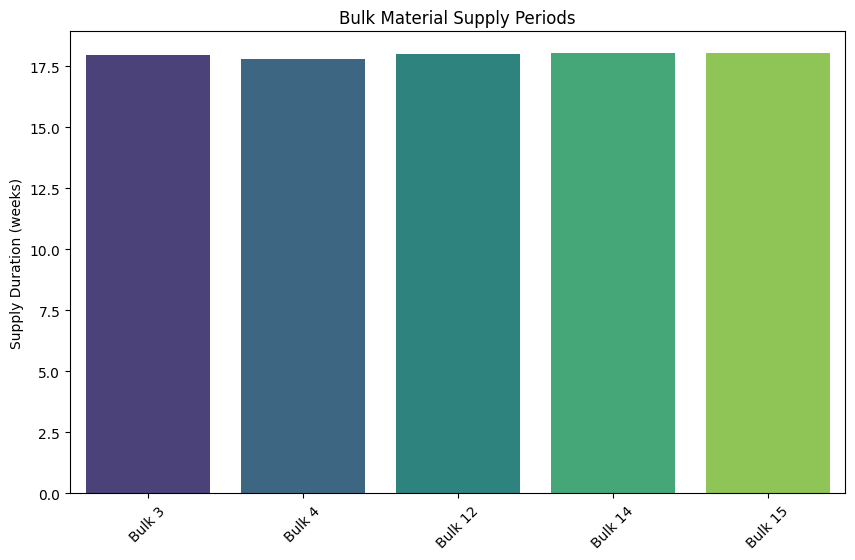

In [30]:
# Calculate the total duration (in weeks) for each bulk material supply
durations_weeks = {
    col: (data_bulk_time[col].max() - data_bulk_time[col].min()).total_seconds() / (86400 * 7)
    for col in data_bulk_time.columns
}

# Generate visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=list(durations_weeks.keys()), y=list(durations_weeks.values()), palette='viridis')
plt.ylabel('Supply Duration (weeks)')
plt.title('Bulk Material Supply Periods')
plt.xticks(rotation=45)
plt.show()

All recorded bulk materials were supplied over a consistent period of approximately 17.6 weeks. This indicates a stable data collection window across all relevant materials.

### Gas Purging Data

In [31]:
data_gas.info()
display(data_gas.head(5))
display(data_gas.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


- No missing values were found, and the data types are appropriate for the analysis.
- The data appears to contain outliers, and the distribution is right-skewed.
- We need to rename the second parameter to English, convert it to snake_case, and set the batch key as the index.

In [32]:
# Dictionary for column renaming
translation_dict = {'Газ 1': 'gas_1'}

# Rename the column to English snake_case
data_gas = data_gas.rename(columns=translation_dict)

# Set 'key' as the index
data_gas = data_gas.set_index('key')

# Verification of the changes
data_gas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gas_1   3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB


#### Distribution Analysis

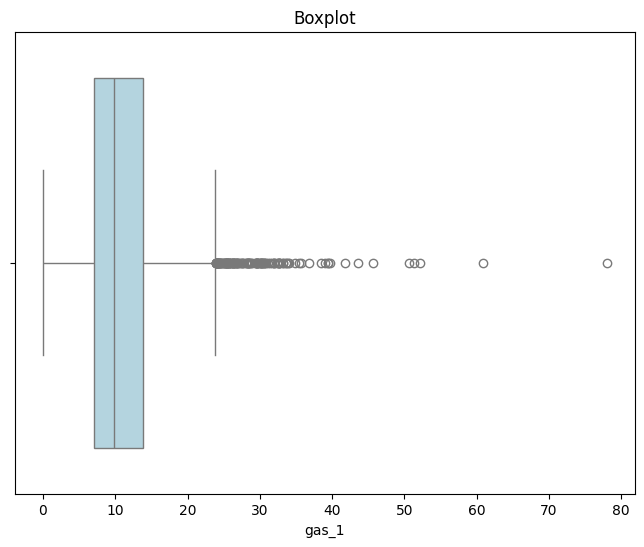

In [33]:
# Visualize the distribution using a boxplot
boxplot(data_gas, 'gas_1')

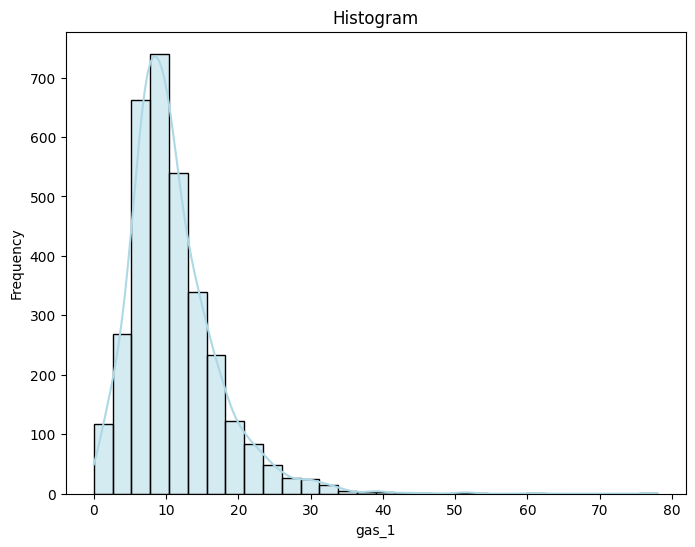

In [34]:
# Visualize the distribution using a histogram
hist(data_gas, 'gas_1', 30)

The distribution of gas purging is right-skewed, with the median and mean both centered around 10. This suggests that in most cases, gas was supplied in relatively small quantities. However, the presence of large values (outliers) pulls the tail of the distribution to the right, representing batches with significantly higher gas consumption.

### Temperature Measurement Results

In [35]:
data_temp.info()
display(data_temp.head(5))
display(data_temp.tail(1))
display(data_temp.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  object 
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 424.2+ KB


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


,key,Время замера,Температура
18091,3241,2019-09-06 17:30:05,NaN


,key,Температура
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000


#### Distribution Analysis

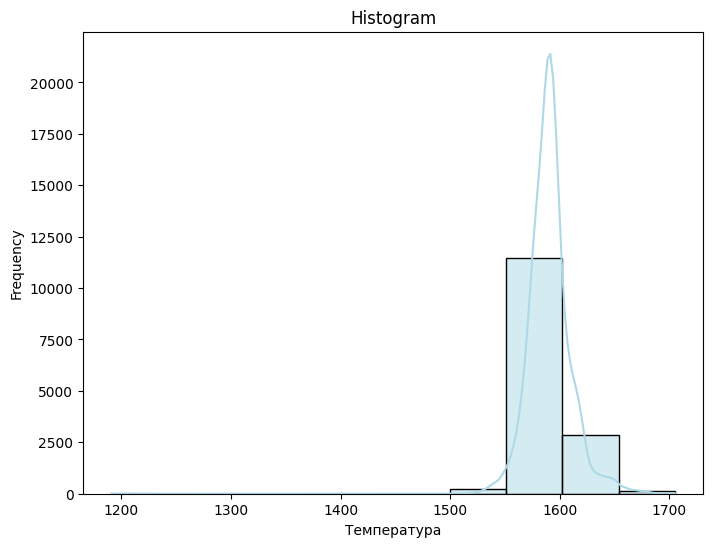

In [36]:
# Visualize the temperature distribution using a histogram
hist(data_temp, 'Температура', 10)

- Over 3,241 batches, the temperature was measured 18,091 times.
- There are missing values in the Temperature parameter.
- The data type for the measurement time needs to be converted to `datetime64[ns]`.
- Columns need to be renamed to English `snake_case`, and the table should be indexed by key.
- While the upper and lower quartiles are above 1500, the minimum recorded value is 1191. The customer specified that any temperature readings below 1500°C should be removed as they likely represent measurement errors or pre-heating phases.
- Average values are consistently close to 1600°C.

In [37]:
# Dictionary for column renaming
translation_dict = {
    'Время замера': 'datetime',
    'Temperature': 'temperature' # Note: 'Температура' in Russian
}

# Rename columns
data_temp = data_temp.rename(columns={'Время замера': 'datetime', 'Температура': 'temperature'})

# Set 'key' as the index
data_temp = data_temp.set_index('key')

# Convert data type to datetime
data_temp['datetime'] = pd.to_datetime(data_temp['datetime'])

# Remove rows with temperature < 1500°C as per customer instructions
data_temp = data_temp[data_temp['temperature'] > 1500]

# Verify changes
data_temp.info()
display(data_temp.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 14660 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     14660 non-null  datetime64[ns]
 1   temperature  14660 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 343.6 KB


,datetime,temperature
key,,
1,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:25:59,1606.0


Next, we will identify and remove batches that have only a single temperature measurement. Our model requires both an **initial temperature** (feature) and a **final temperature** (target); therefore, batches with only one record are not suitable for training.

We will also extract:
- first_temp: The initial temperature measurement.
- target: The final temperature measurement.
- Duration: The time elapsed between the first and last measurement.

In [38]:
# Remove batches with only one measurement
data_temp = data_temp.groupby('key').filter(lambda x: len(x) > 1)

# Aggregate to keep only the first and last measurements for each batch
data_temp = data_temp.groupby('key').agg(
    first_temp=('temperature', 'first'),
    target=('temperature', 'last'),
    first_datetime=('datetime', 'first'),
    last_datetime=('datetime', 'last')
)

# Show the resulting features
display(data_temp.head(5))

,first_temp,target,first_datetime,last_datetime
key,,,,
1,1571.0,1613.0,2019-05-03 11:02:04,2019-05-03 11:30:38
2,1581.0,1602.0,2019-05-03 11:34:04,2019-05-03 11:55:09
3,1596.0,1599.0,2019-05-03 12:06:44,2019-05-03 12:35:57
4,1601.0,1625.0,2019-05-03 12:39:27,2019-05-03 12:59:47
5,1576.0,1602.0,2019-05-03 13:11:03,2019-05-03 13:36:39


### Wire Material Data

#### Wire Material Data (Volume)

In [39]:
data_wire.info()
display(data_wire.head(5))
display(data_wire.tail(1))
display(data_wire.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
3080,3241,63.117595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


There are 3,080 records compared to 3,241 total batches, which means alloying materials were not added to all batches.
- The table contains missing values. We will remove columns where more than 80% of the data is missing.
- Outliers are present in the first few features.
- Data types are correct.
- We need to rename parameters to snake_case and set the key as the index.

In [40]:
# Define the threshold for dropping columns with missing values (80%)
threshold = 0.8

# Remove columns where more than 80% of values are missing
data_wire = data_wire.dropna(thresh=len(data_wire) * (1 - threshold), axis=1)

# Set 'key' as the index
data_wire = data_wire.set_index('key')

# Fill the remaining missing values with 0 (indicating no material added)
data_wire = data_wire.fillna(0)

In [41]:
# Dictionary for column renaming
translation_dict = {
    'Wire 1': 'wire_1',
    'Wire 2': 'wire_2'
}

# Rename columns to English snake_case
data_wire = data_wire.rename(columns=translation_dict)

# Verify the results
data_wire.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   wire_1  3081 non-null   float64
 1   wire_2  3081 non-null   float64
dtypes: float64(2)
memory usage: 72.2 KB


#### Distribution Analysis

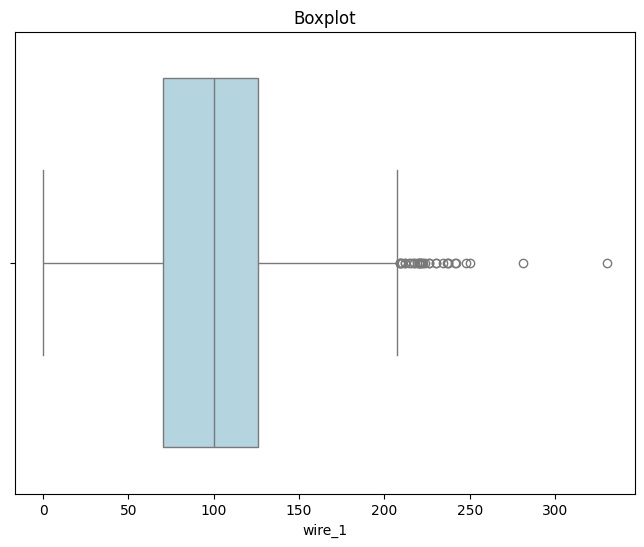

In [42]:
# Distribution for wire_1
boxplot(data_wire, 'wire_1')

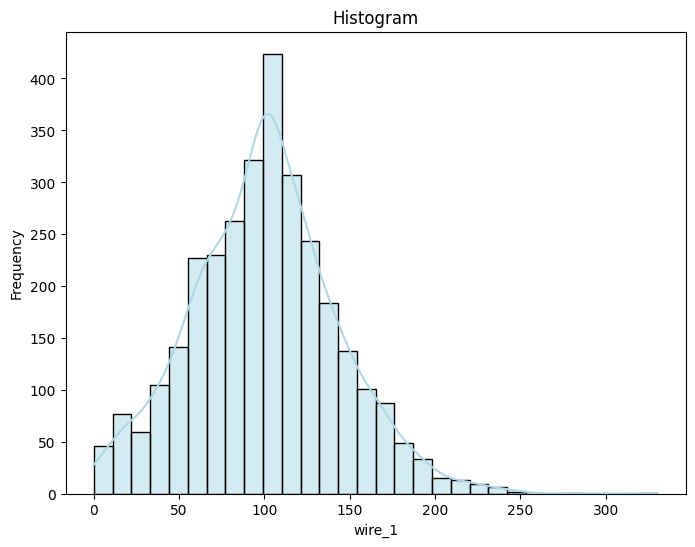

In [43]:
hist(data_wire, 'wire_1', 30)

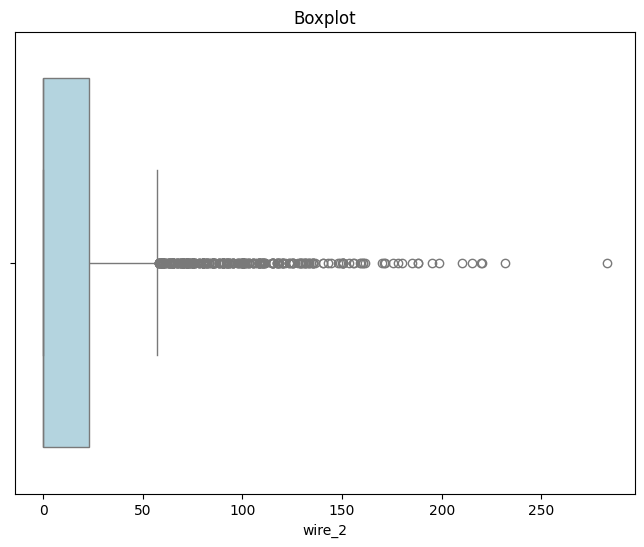

In [44]:
# Distribution for wire_2
boxplot(data_wire, 'wire_2')

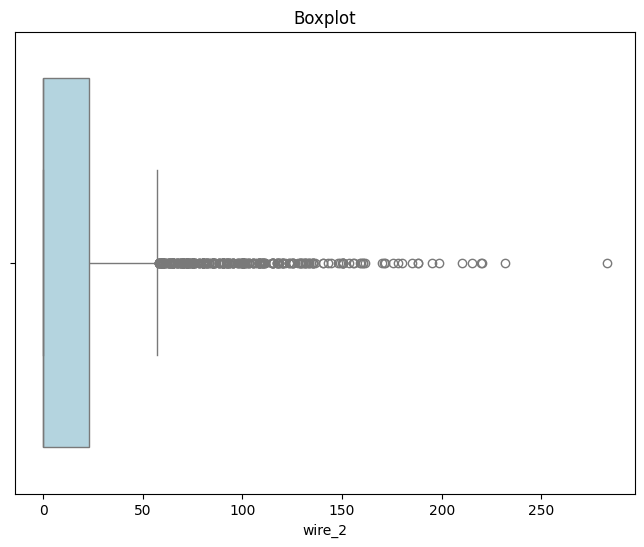

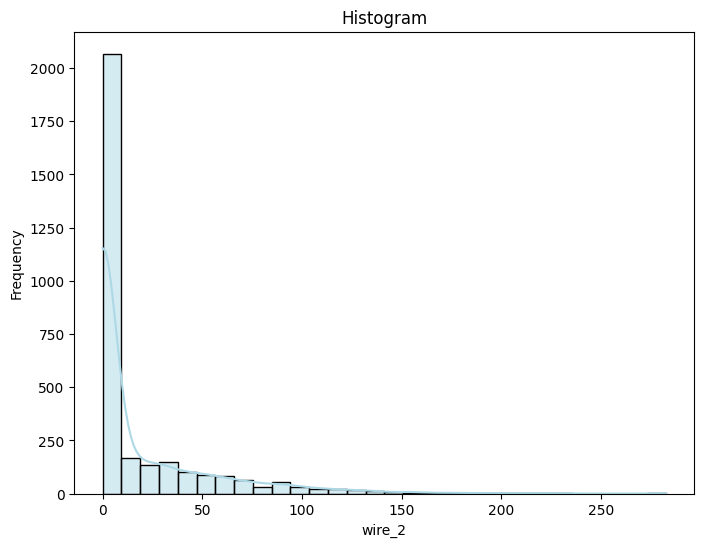

In [45]:
boxplot(data_wire, 'wire_2')
hist(data_wire, 'wire_2', 30)

- `wire_1`: The distribution is right-skewed, with both the mean and median centered around 100. Significant outliers are present.
- `wire_2`: Also right-skewed, with a mean of 50 and a median of 40. It features a long tail of outliers.

#### Correlation Analysis

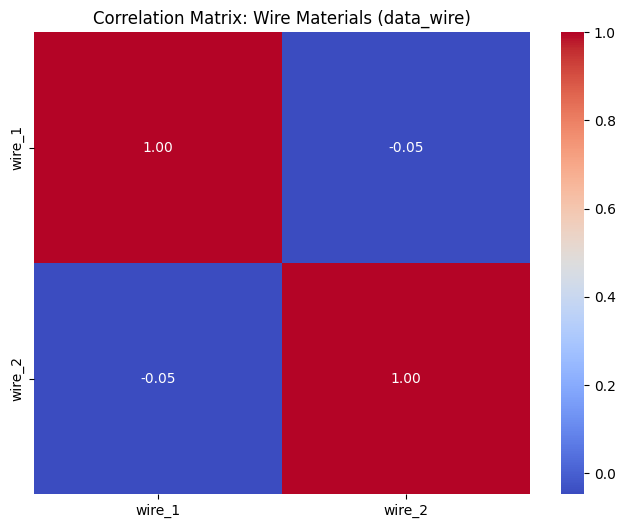

In [46]:
# Visualize correlation between wire parameters
plt.figure(figsize=(8, 6))
sns.heatmap(data_wire.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Wire Materials (data_wire)')
plt.show()

There is no significant correlation (0.00) between `wire_1` and `wire_2`.

### Wire Material Data (Time)

In [47]:
data_wire_time.info()
display(data_wire_time.head(5))
display(data_wire_time.tail(1))
display(data_wire_time.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
3080,3241,2019-09-06 17:10:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,key
count,3081.000000
mean,1623.426485
std,932.996726
min,1.000000
25%,823.000000
50%,1619.000000
75%,2434.000000
max,3241.000000


We can observe that the structures of the `data_wire` and `data_wire_time` tables are identical. It is necessary to convert the data types to `datetime64[ns]` and index the table by the batch key.

In [48]:
# Set 'key' as the index
data_wire_time = data_wire_time.set_index('key')

# Keep only columns that correspond to those retained in data_wire (usage > 20%)
data_wire_time = data_wire_time[['Wire 1', 'Wire 2']]

# Convert the data to datetime format for each column
data_wire_time['Wire 1'] = pd.to_datetime(data_wire_time['Wire 1'], errors='coerce')
data_wire_time['Wire 2'] = pd.to_datetime(data_wire_time['Wire 2'], errors='coerce')

# Verification
print(data_wire_time.info())
display(data_wire_time.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Wire 1  3055 non-null   datetime64[ns]
 1   Wire 2  1079 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 72.2 KB
None


,Wire 1,Wire 2
key,,
1,2019-05-03 11:06:19,NaT
2,2019-05-03 11:36:50,NaT
3,2019-05-03 12:11:46,NaT
4,2019-05-03 12:43:22,NaT
5,2019-05-03 13:20:44,2019-05-03 13:15:34


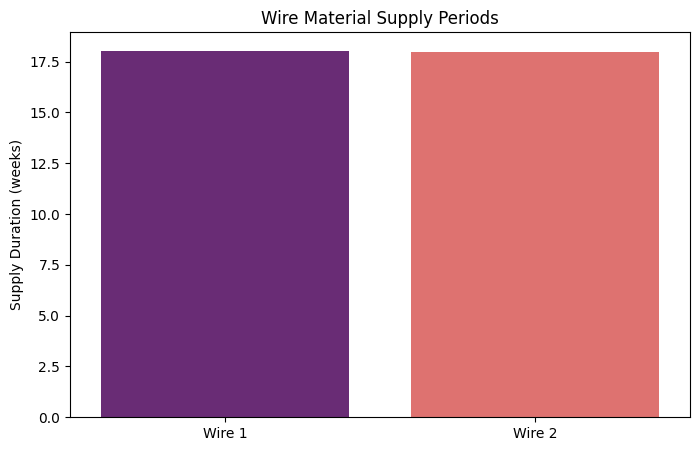

In [49]:
# Calculate the duration between max and min timestamps for relevant columns
durations_weeks = {
    col: (data_wire_time[col].max() - data_wire_time[col].min()).total_seconds() / (86400 * 7)
    for col in ['Wire 1', 'Wire 2']
}

# Visualize the supply duration
plt.figure(figsize=(8, 5))
sns.barplot(x=list(durations_weeks.keys()), y=list(durations_weeks.values()), palette='magma')
plt.ylabel('Supply Duration (weeks)')
plt.title('Wire Material Supply Periods')
plt.show()

Similar to the bulk materials, all wire materials were supplied over a period of approximately 17.6 weeks.

### General Conclusion of EDA

During the exploratory analysis, we examined all provided datasets describing various stages of the steel treatment process (arc heating, bulk and wire material additions, gas purging, and temperature measurements).

**Key Findings and Actions Performed:**

- Data Types: Corrected timestamp formats for all relevant columns.
- Missing Values: Interpreted missing values in additive volumes (bulk/wire) as zero usage.
- Filtering: Removed temperature records below 1500°C and excluded batches with only a single temperature measurement.
- Anomalies: Eliminated technical errors, such as the negative reactive power record.
- Standardization: All column names were converted to snake_case.


**To improve future model performance:**
- Removed wire material columns with more than 80% missing values.
- Removed bulk material columns used in less than 20% of batches.

**Data Properties:**
- Most numerical features (power, gas, addition volumes) are right-skewed and contain outliers.
- A moderate correlation was found between specific bulk materials (Bulk 12, 14, 15), suggesting they are often added together.

**Preparation for Modeling:**
- Identified the critical features: the initial temperature (first_temp) and the target variable (target).

## <a name='Engineering'></a> Feature Engineering

We will create the following parameters:
- `time_between`: The total time (in seconds) elapsed between the first and last temperature measurements.
- `iteration_num_arc`: The total count of heating cycles (iterations) for each batch.
- `mean_time_per_iter`: The average duration of a single heating iteration.
- `sum_heating_duration`: The total accumulated time the electrodes were heating the steel in a given batch.

In [50]:
# Calculate the time between the first and last measurement (in minutes)
data_temp['time_between_temp'] = (data_temp['last_datetime'] - data_temp['first_datetime']).dt.total_seconds() / 60

# Remove unnecessary time columns from data_temp
data_temp = data_temp.drop(columns=['first_datetime', 'last_datetime'])

# Create new features: number of arc iterations and duration per iteration
data_arc['iteration_num_arc'] = iteration_num_arc
data_arc['time_per_iter_arc'] = time_per_iter_arc

# Calculate the total heating duration per batch (by 'key')
data_arc['sum_time_per_key'] = data_arc.groupby('key')['time_per_iter_arc'].transform('sum')

# Remove unnecessary time columns from data_arc
data_arc = data_arc.drop(columns=['arc_heating_start', 'arc_heating_end'])

# Verify the updated dataframes
display(data_temp.info())
display(data_arc.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2475 entries, 1 to 2499
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   first_temp         2475 non-null   float64
 1   target             2475 non-null   float64
 2   time_between_temp  2475 non-null   float64
dtypes: float64(3)
memory usage: 77.3 KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 14875 entries, 1 to 3241
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   active_power       14875 non-null  float64
 1   reactive_power     14875 non-null  float64
 2   iteration_num_arc  14875 non-null  int64  
 3   time_per_iter_arc  14875 non-null  float64
 4   sum_time_per_key   14875 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 697.3 KB


None

## <a name='Merging'></a> Data Merging

Before merging the datasets, we will perform an aggregation of the data_arc table to ensure we have one unique record per batch.

In [51]:
# Aggregate data by the key (batch)
data_arc = data_arc.groupby('key').agg(
    {
        'active_power': 'median',       # Median value for active power
        'reactive_power': 'median',     # Median value for reactive power
        'time_per_iter_arc': 'mean',    # Mean time per iteration
        'iteration_num_arc': 'first',   # Number of iterations in the batch
        'sum_time_per_key': 'first'     # Total heating time per batch
    })

# Verify the aggregated data structure
data_arc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3214 entries, 1 to 3241
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   active_power       3214 non-null   float64
 1   reactive_power     3214 non-null   float64
 2   time_per_iter_arc  3214 non-null   float64
 3   iteration_num_arc  3214 non-null   int64  
 4   sum_time_per_key   3214 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 150.7 KB


In [52]:
# List of all datasets to be merged
datasets = [data_arc, data_bulk, data_gas, data_temp, data_wire]

# Merge all datasets sequentially using reduce with an inner join on the index
from functools import reduce
df = reduce(lambda left, right: left.merge(right, left_index=True, right_index=True, how='inner'), datasets)

# Display the first few and last rows of the merged dataset
display(df.head(5))
display(df.tail(1))

,active_power,reactive_power,time_per_iter_arc,iteration_num_arc,sum_time_per_key,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,gas_1,first_temp,target,time_between_temp,wire_1,wire_2
key,,,,,,,,,,,,,,,,
1,0.580313,0.430460,3.660000,5,18.300000,0.0,43.0,206.0,150.0,154.0,29.749986,1571.0,1613.0,28.566667,60.059998,0.00000
2,0.545710,0.352656,3.379167,4,13.516667,0.0,73.0,206.0,149.0,154.0,12.555561,1581.0,1602.0,21.083333,96.052315,0.00000
3,0.774632,0.505690,2.183333,5,10.916667,0.0,34.0,205.0,152.0,153.0,28.554793,1596.0,1599.0,29.216667,91.160157,0.00000
4,0.753970,0.580275,3.087500,4,12.350000,0.0,81.0,207.0,153.0,154.0,18.841219,1601.0,1625.0,20.333333,89.063515,0.00000
5,0.517715,0.374041,3.620833,4,14.483333,0.0,78.0,203.0,151.0,152.0,5.413692,1576.0,1602.0,25.600000,89.238236,9.11456


,active_power,reactive_power,time_per_iter_arc,iteration_num_arc,sum_time_per_key,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,gas_1,first_temp,target,time_between_temp,wire_1,wire_2
key,,,,,,,,,,,,,,,,
2499,0.370014,0.266499,3.679167,4,14.716667,47.0,0.0,233.0,126.0,227.0,11.336151,1569.0,1603.0,25.616667,110.160958,50.00528


Great, we don't have keys with numbers greater than 2500 as per the task requirement.

## <a name='Merged'></a> EDA and Preprocessing of the Merged Dataset

In [53]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 2329 entries, 1 to 2499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   active_power       2329 non-null   float64
 1   reactive_power     2329 non-null   float64
 2   time_per_iter_arc  2329 non-null   float64
 3   iteration_num_arc  2329 non-null   int64  
 4   sum_time_per_key   2329 non-null   float64
 5   bulk_3             2329 non-null   float64
 6   bulk_4             2329 non-null   float64
 7   bulk_12            2329 non-null   float64
 8   bulk_14            2329 non-null   float64
 9   bulk_15            2329 non-null   float64
 10  gas_1              2329 non-null   float64
 11  first_temp         2329 non-null   float64
 12  target             2329 non-null   float64
 13  time_between_temp  2329 non-null   float64
 14  wire_1             2329 non-null   float64
 15  wire_2             2329 non-null   float64
dtypes: float64(15), int64(1)
memo

,active_power,reactive_power,time_per_iter_arc,iteration_num_arc,sum_time_per_key,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,gas_1,first_temp,target,time_between_temp,wire_1,wire_2
count,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000
mean,0.635343,0.466244,2.867174,4.695148,13.460011,47.348218,37.303564,208.415629,153.853585,119.952769,11.375600,1587.386003,1593.365393,38.696837,102.443601,17.609859
std,0.151622,0.113304,0.729031,1.606948,5.681622,75.310430,58.643238,157.062272,81.404354,84.640443,6.392041,23.619841,11.200915,23.086525,43.539993,33.624771
min,0.235282,0.167425,0.950000,1.000000,0.950000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008399,1519.000000,1541.000000,4.500000,0.000000,0.000000
25%,0.521240,0.382405,2.350000,4.000000,9.683333,0.000000,0.000000,105.000000,105.000000,0.000000,7.282948,1571.000000,1587.000000,26.316667,73.207679,0.000000
50%,0.613501,0.451968,2.825000,5.000000,12.966667,0.000000,0.000000,206.000000,149.000000,107.000000,10.100950,1587.000000,1593.000000,34.083333,101.119201,0.000000
75%,0.725005,0.534515,3.312500,6.000000,16.550000,80.000000,77.000000,282.000000,204.000000,204.000000,14.216688,1603.000000,1598.000000,46.516667,128.091599,23.102560
max,1.268378,0.995877,6.300000,16.000000,69.816667,454.000000,281.000000,1849.000000,636.000000,405.000000,77.995040,1660.000000,1653.000000,394.566667,330.314424,282.780152


- We have successfully finalized the dataset with a total of 2,332 records.
- Parameters: 15 features (excluding the index).
- Missing Values: None (cleaned during the merge).
- Outliers are present in several parameters, which we will visualize below.

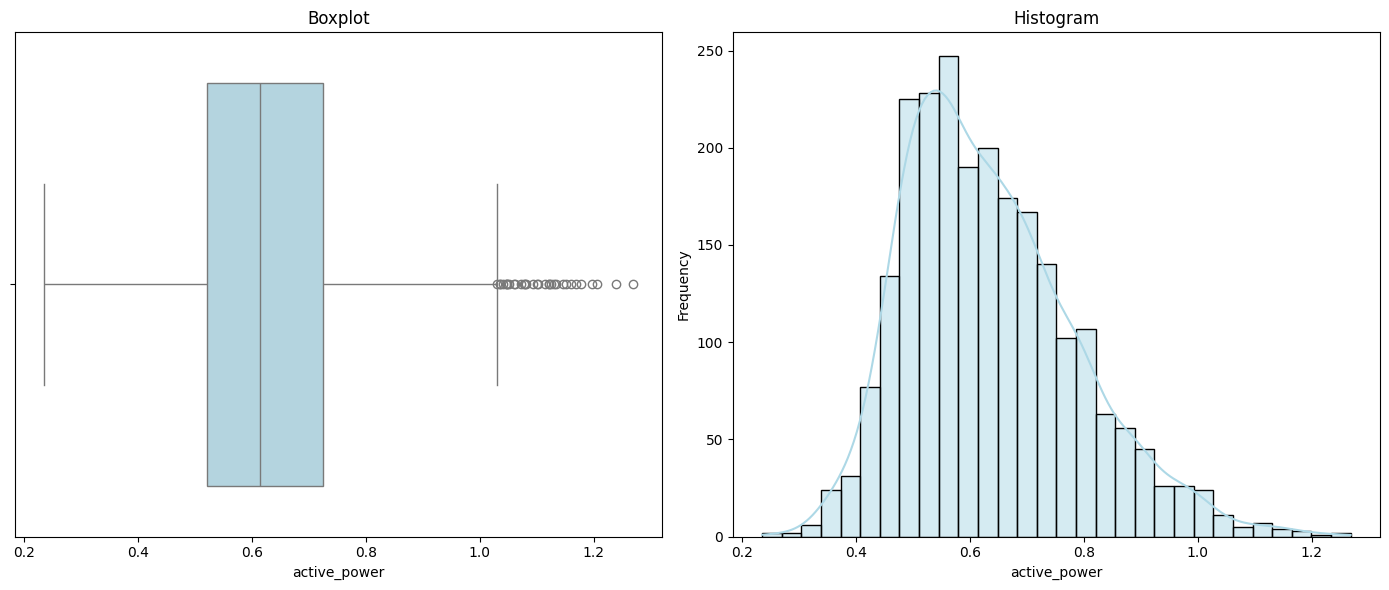

In [54]:
# Visualizing the distributions for all features in the merged dataset
plot_distribution(df, 'active_power', 30)

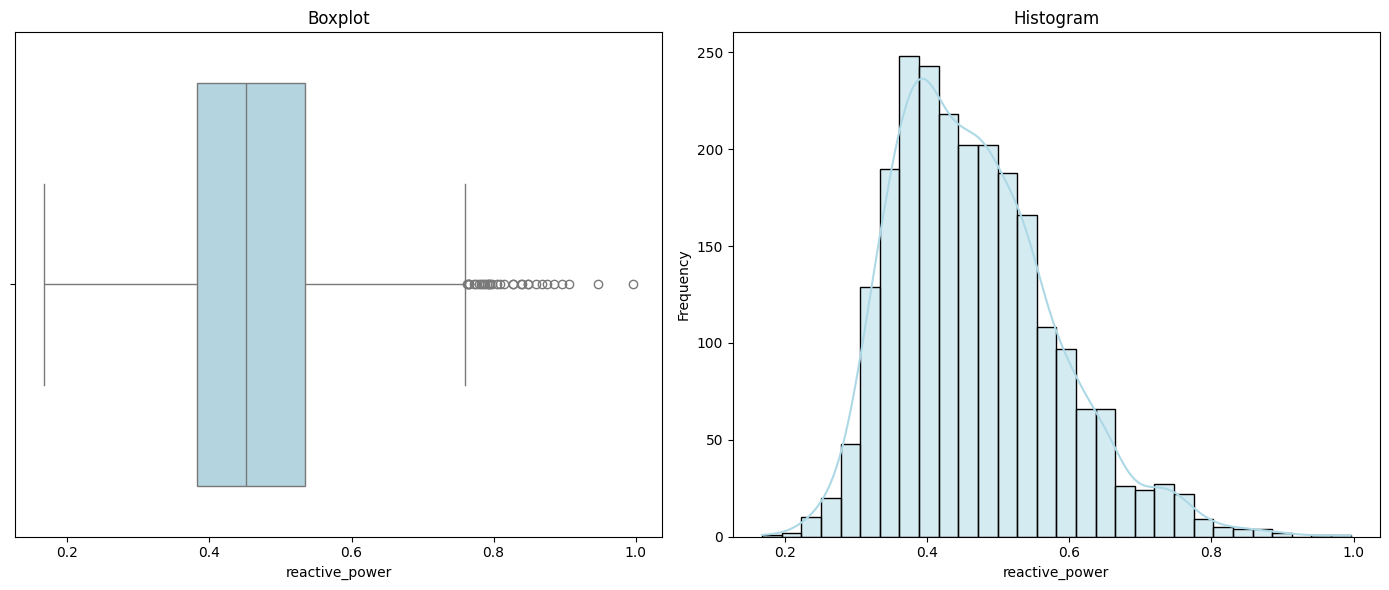

In [55]:
plot_distribution(df, 'reactive_power', 30)

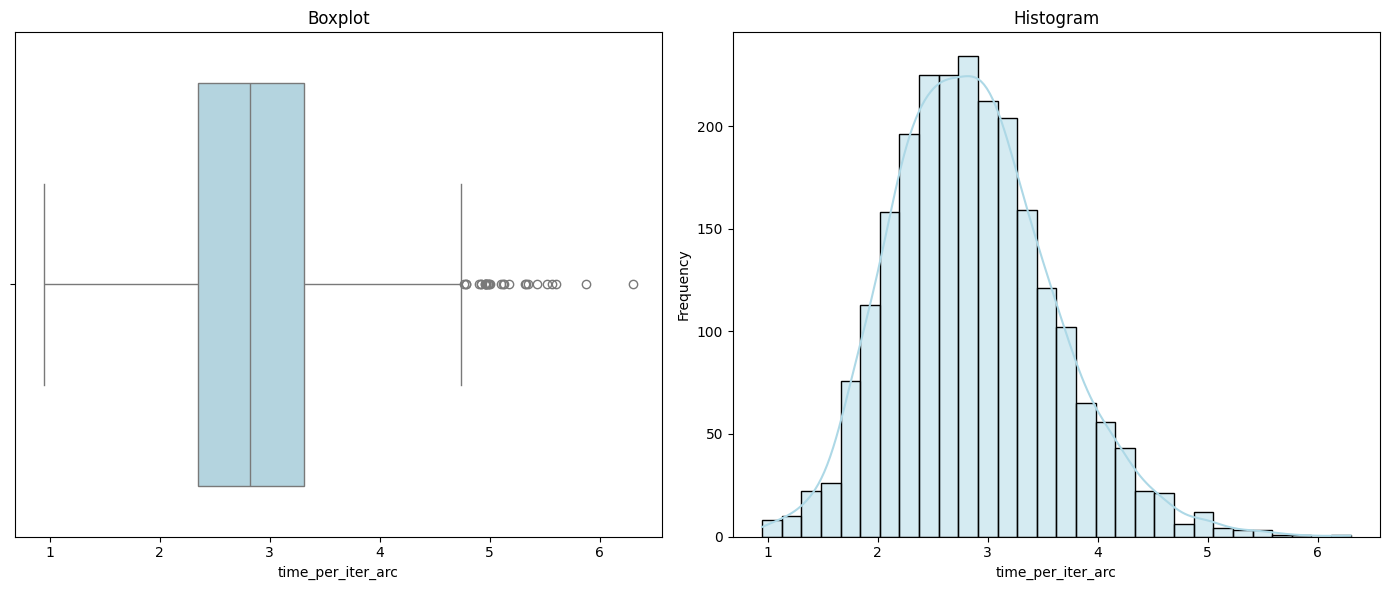

In [56]:
plot_distribution(df, 'time_per_iter_arc', 30)

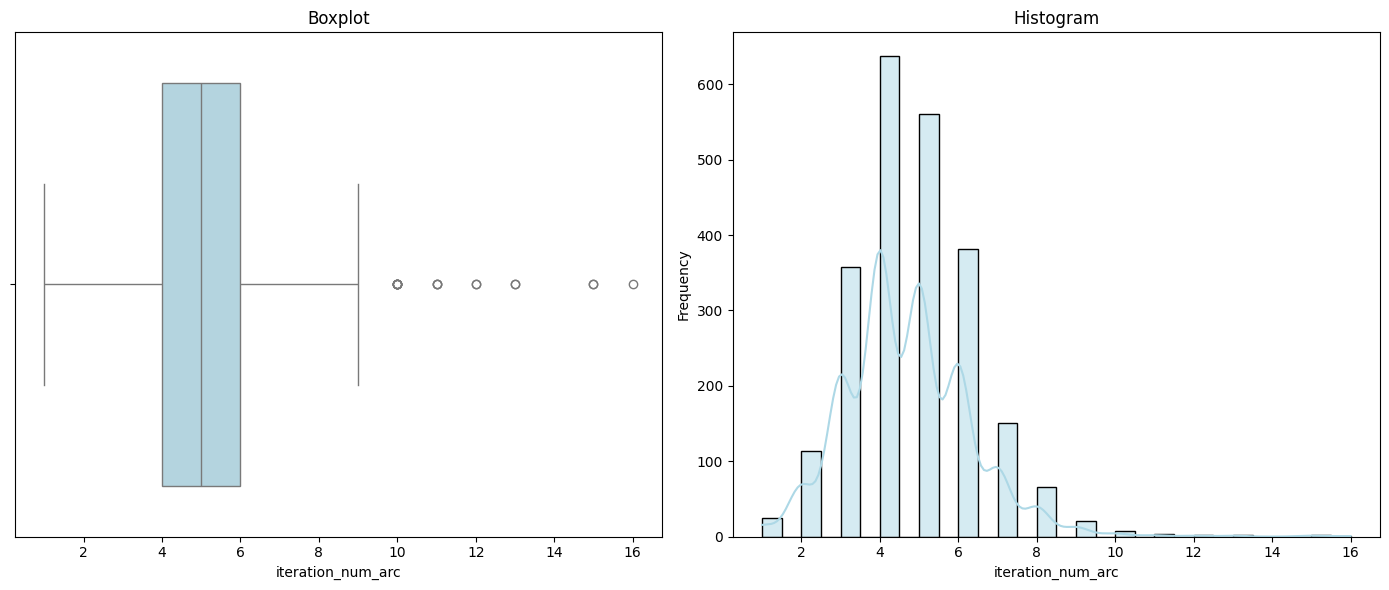

In [57]:
plot_distribution(df, 'iteration_num_arc', 30)

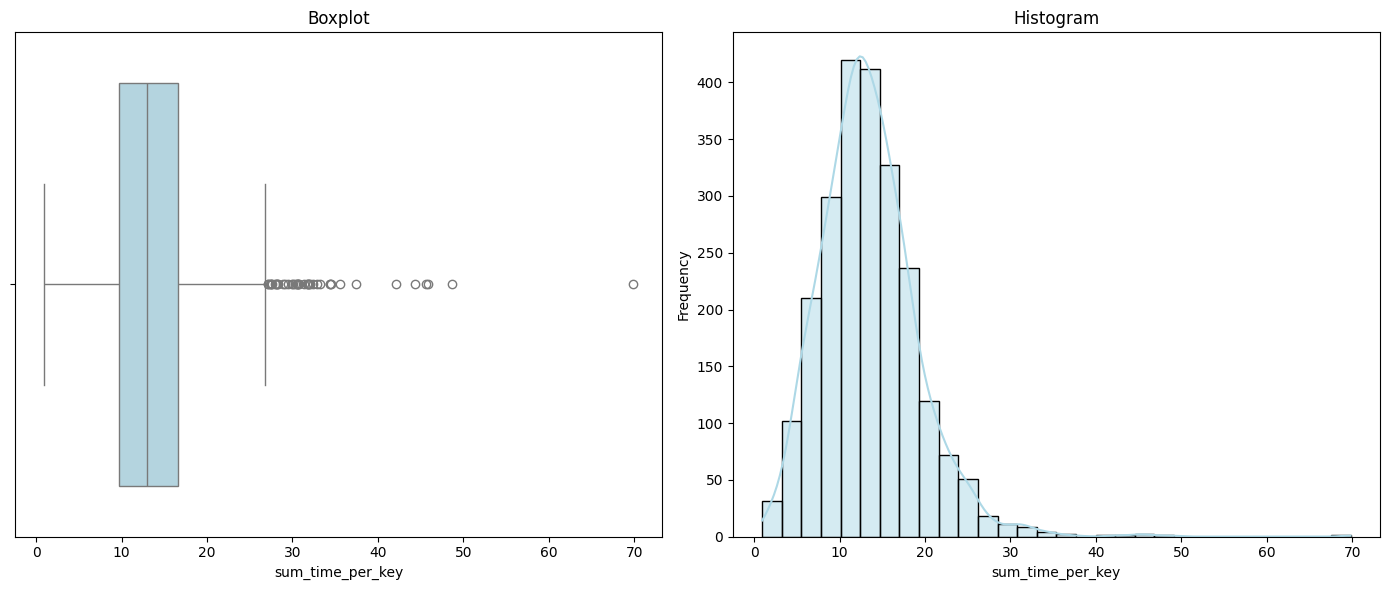

In [58]:
plot_distribution(df, 'sum_time_per_key', 30)

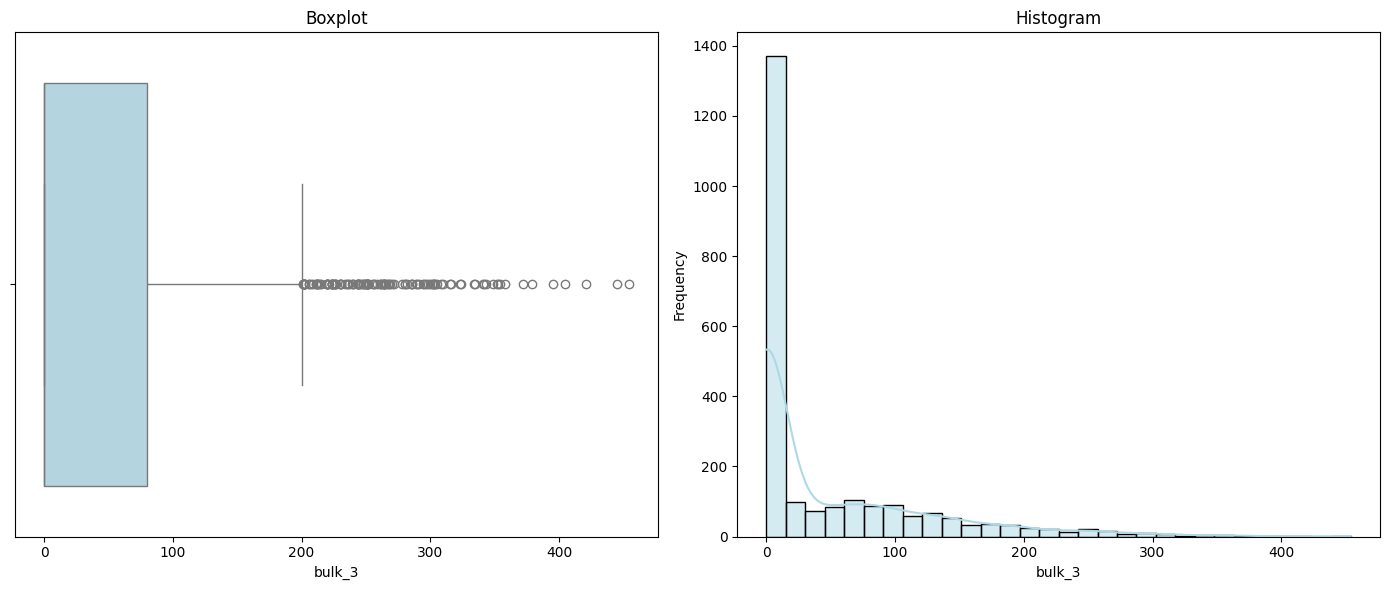

In [59]:
plot_distribution(df, 'bulk_3', 30)

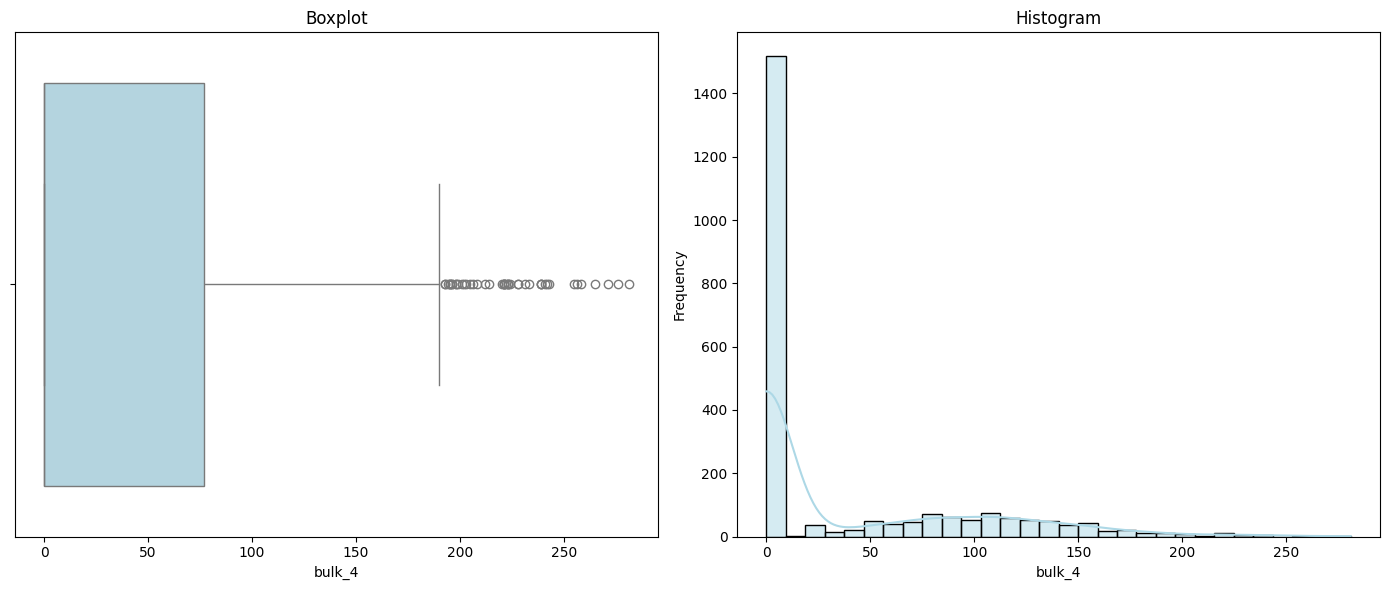

In [60]:
plot_distribution(df, 'bulk_4', 30)

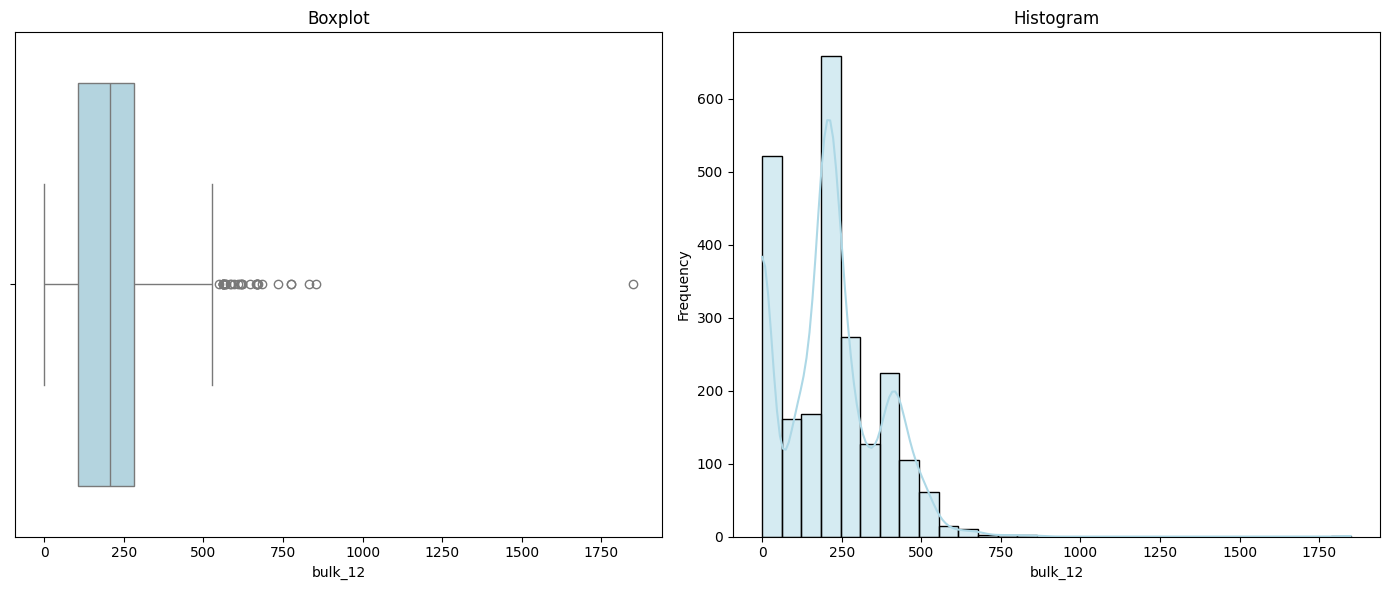

In [61]:
plot_distribution(df, 'bulk_12', 30)

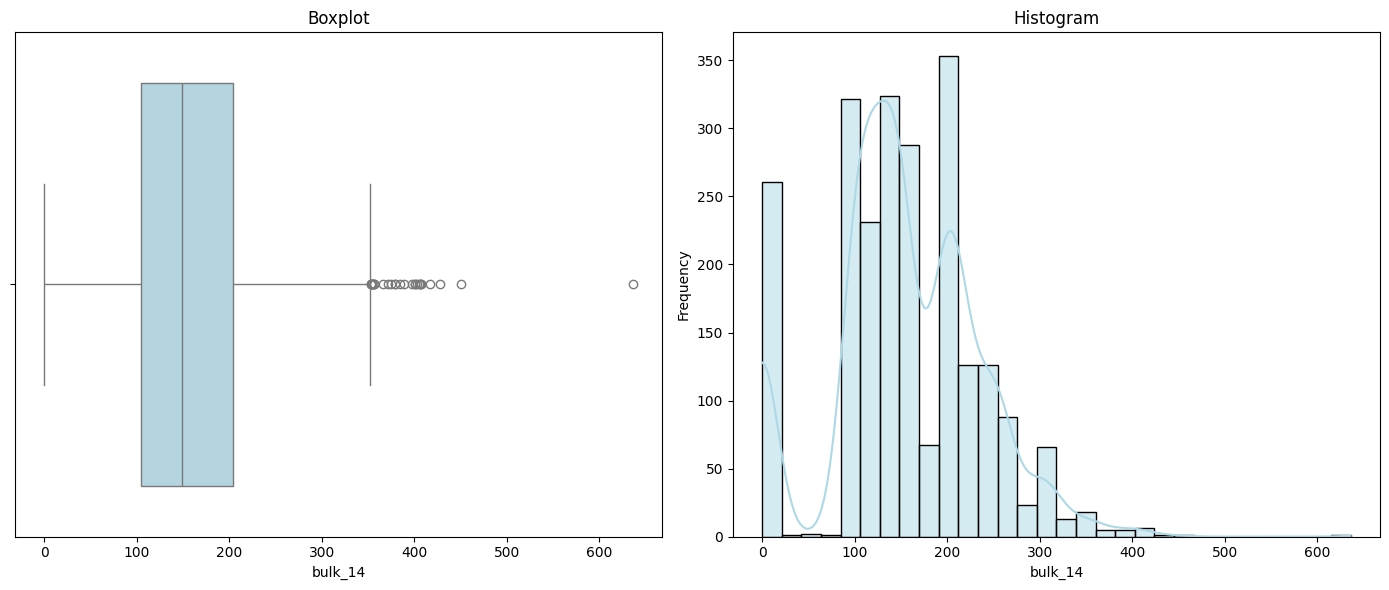

In [62]:
plot_distribution(df, 'bulk_14', 30)

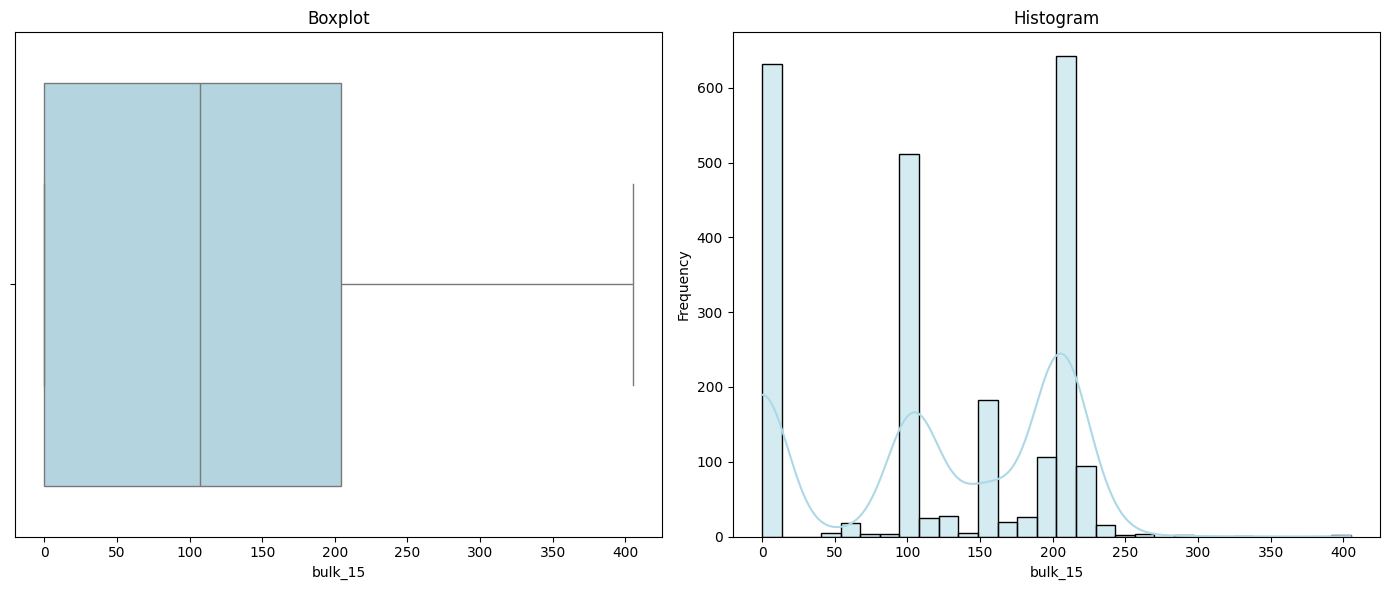

In [63]:
plot_distribution(df, 'bulk_15', 30)

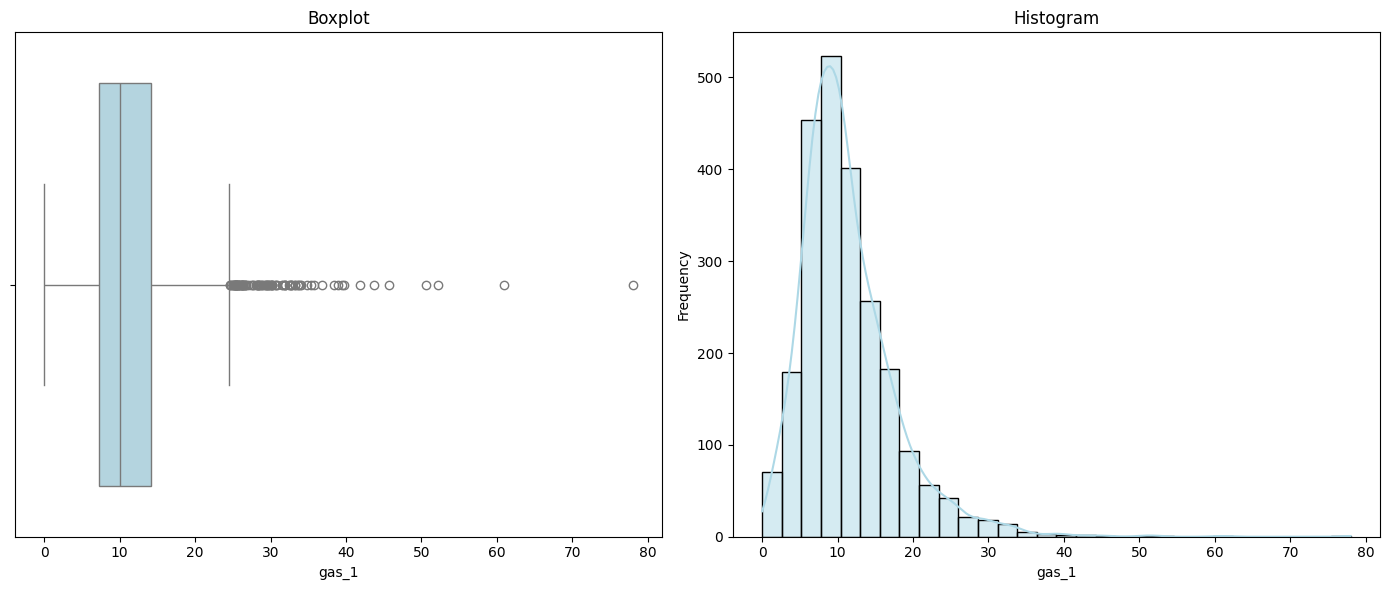

In [64]:
plot_distribution(df, 'gas_1', 30)

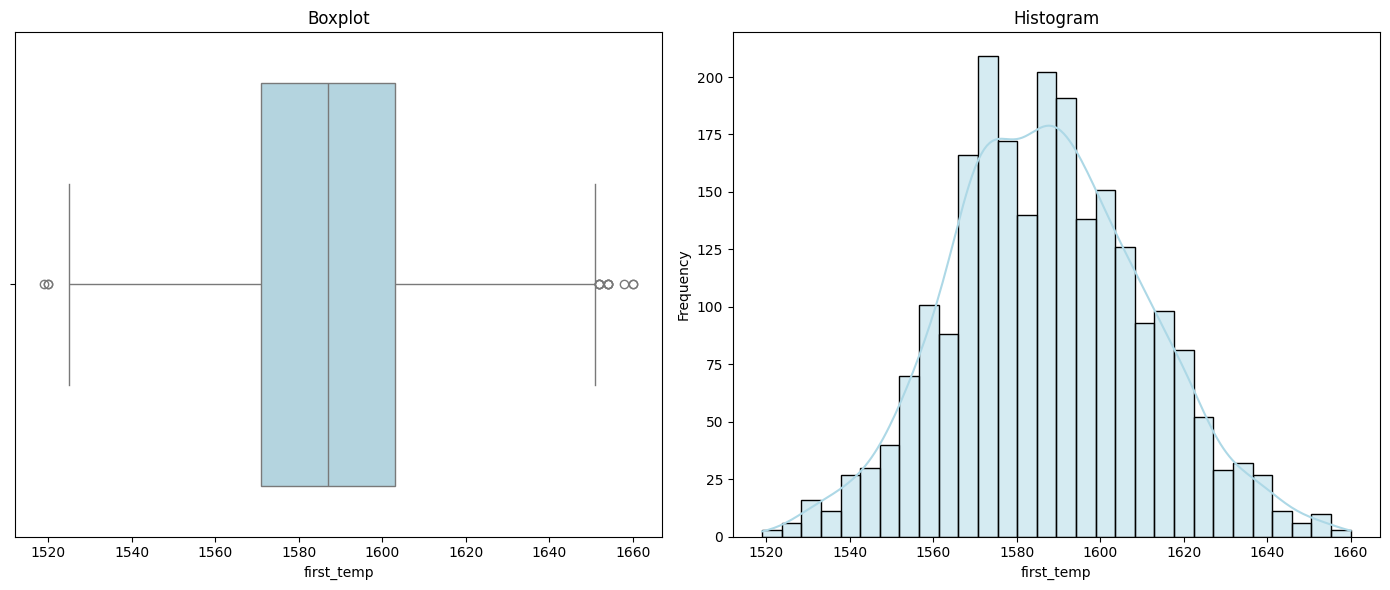

In [65]:
plot_distribution(df, 'first_temp', 30)

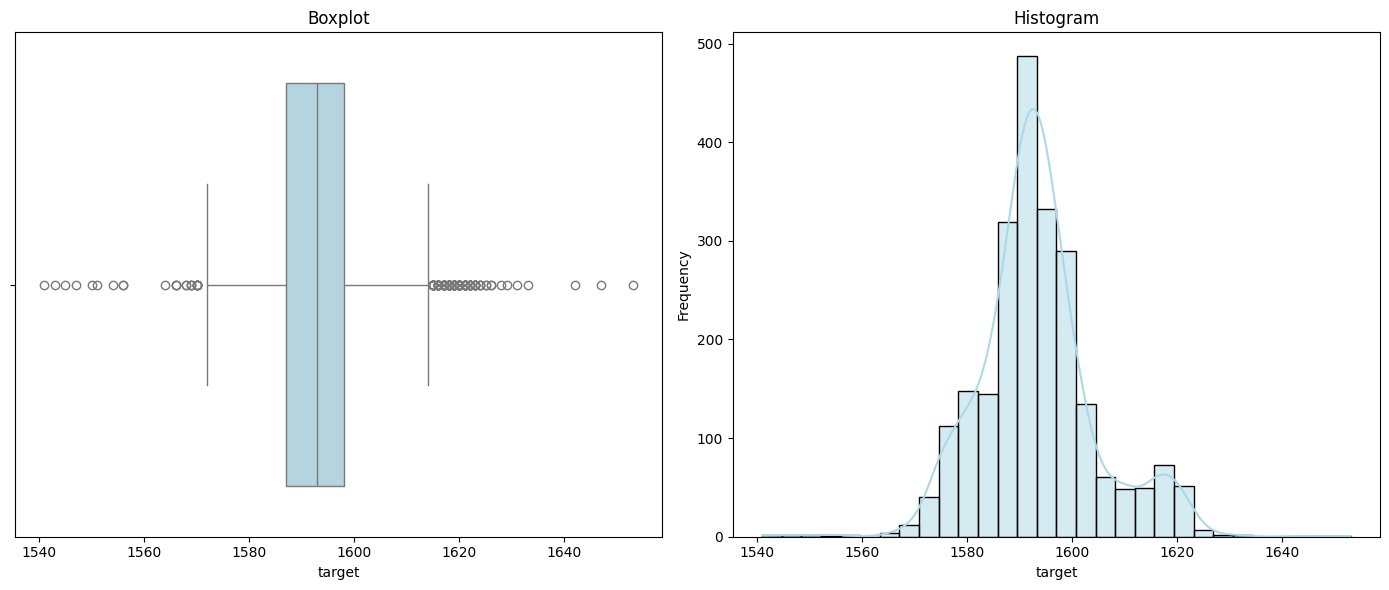

In [66]:
plot_distribution(df, 'target', 30)

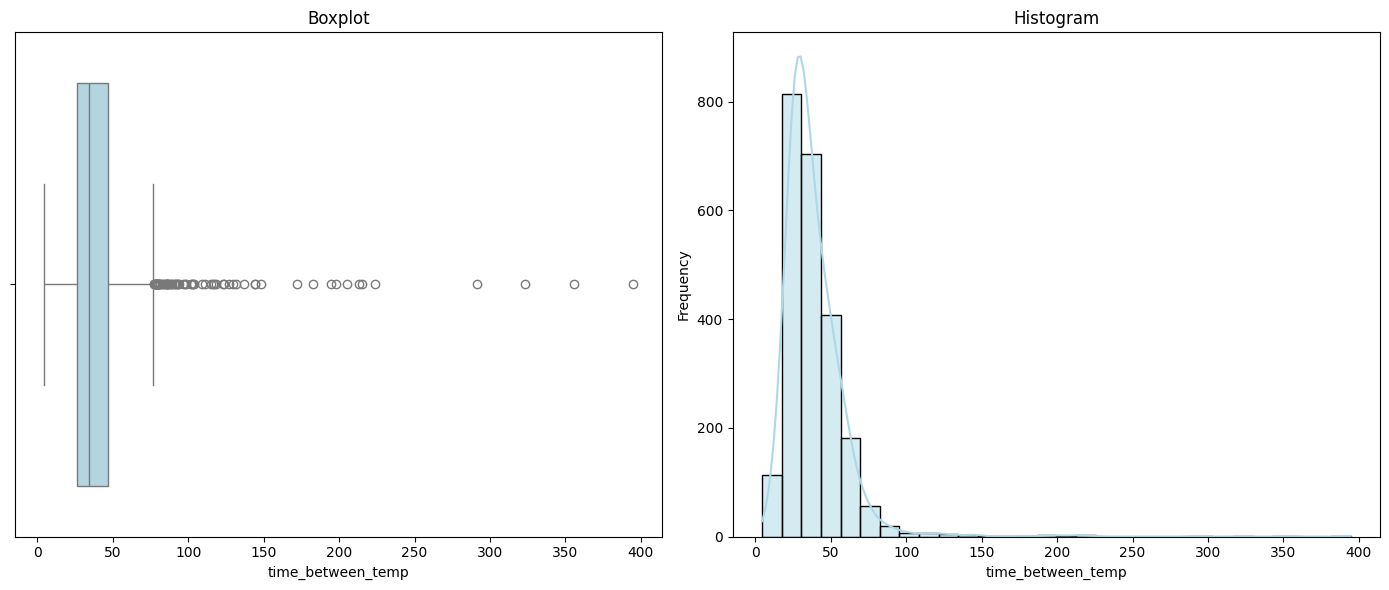

In [67]:
plot_distribution(df, 'time_between_temp', 30)

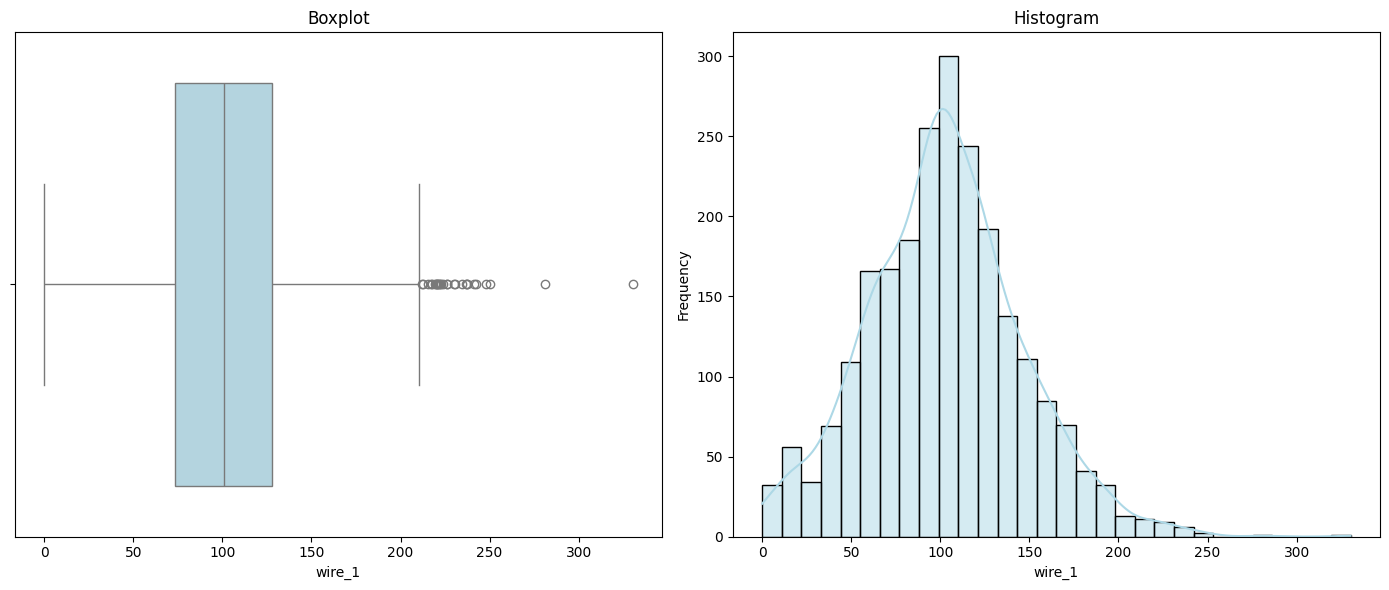

In [68]:
plot_distribution(df, 'wire_1', 30)

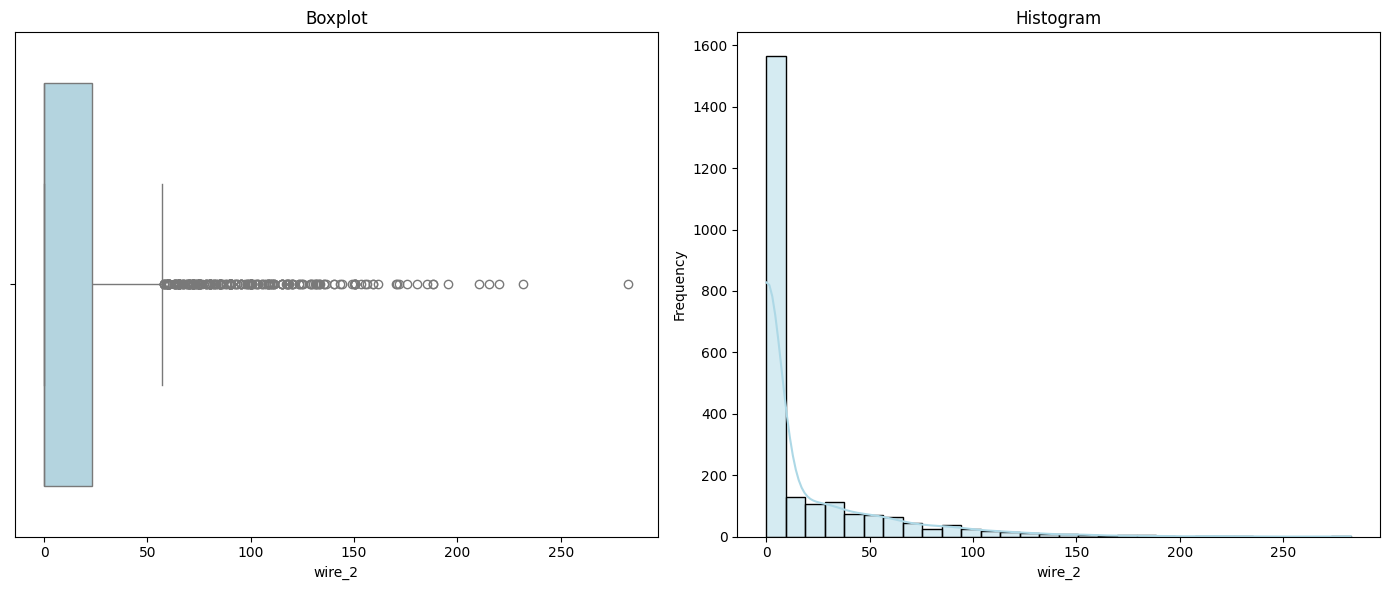

In [69]:
plot_distribution(df, 'wire_2', 30)

- **Prevalence of Right Skewness**: Most input features (active_power, reactive_power, gas_1, time_between_temp, wire_1, wire_2, bulk_3, bulk_4, iteration_num_arc, time_per_iter_arc) exhibit right-skewed distributions. This indicates that for the majority of batches, these parameters remain within the lower or middle range, while a few specific operations involve significantly higher values (forming long "tails" to the right).

- **Presence of Outliers**: Nearly all analyzed numerical features contain outliers, primarily upper outliers. This highlights the presence of atypical values within the technological process data.

- **Multimodality**: Certain features (bulk_12, bulk_15, first_temp) show multimodal distributions (multiple peaks). This may suggest the existence of several distinct operating modes or standard dosage levels used during production.

- **Target Variable**: The distribution of the final temperature (target) is approximately normal, centered around 1593°C. This is a favorable characteristic for regression models. However, outliers are also present in the target variable.

- **Features with High Proportions of Low/Zero Values**: Features such as bulk_3, bulk_4, and wire_2 are heavily shifted toward low values (frequently zero), reflecting the specific nature of their application in the metallurgical process.

The presence of skewness and outliers across many features necessitates data scaling (e.g., StandardScaler) before training scale-sensitive linear models. Tree-based models may be less affected by these distribution properties. The distribution of the target variable is well-behaved and does not require specific transformations.

### Correlation Analysis and Feature Selection

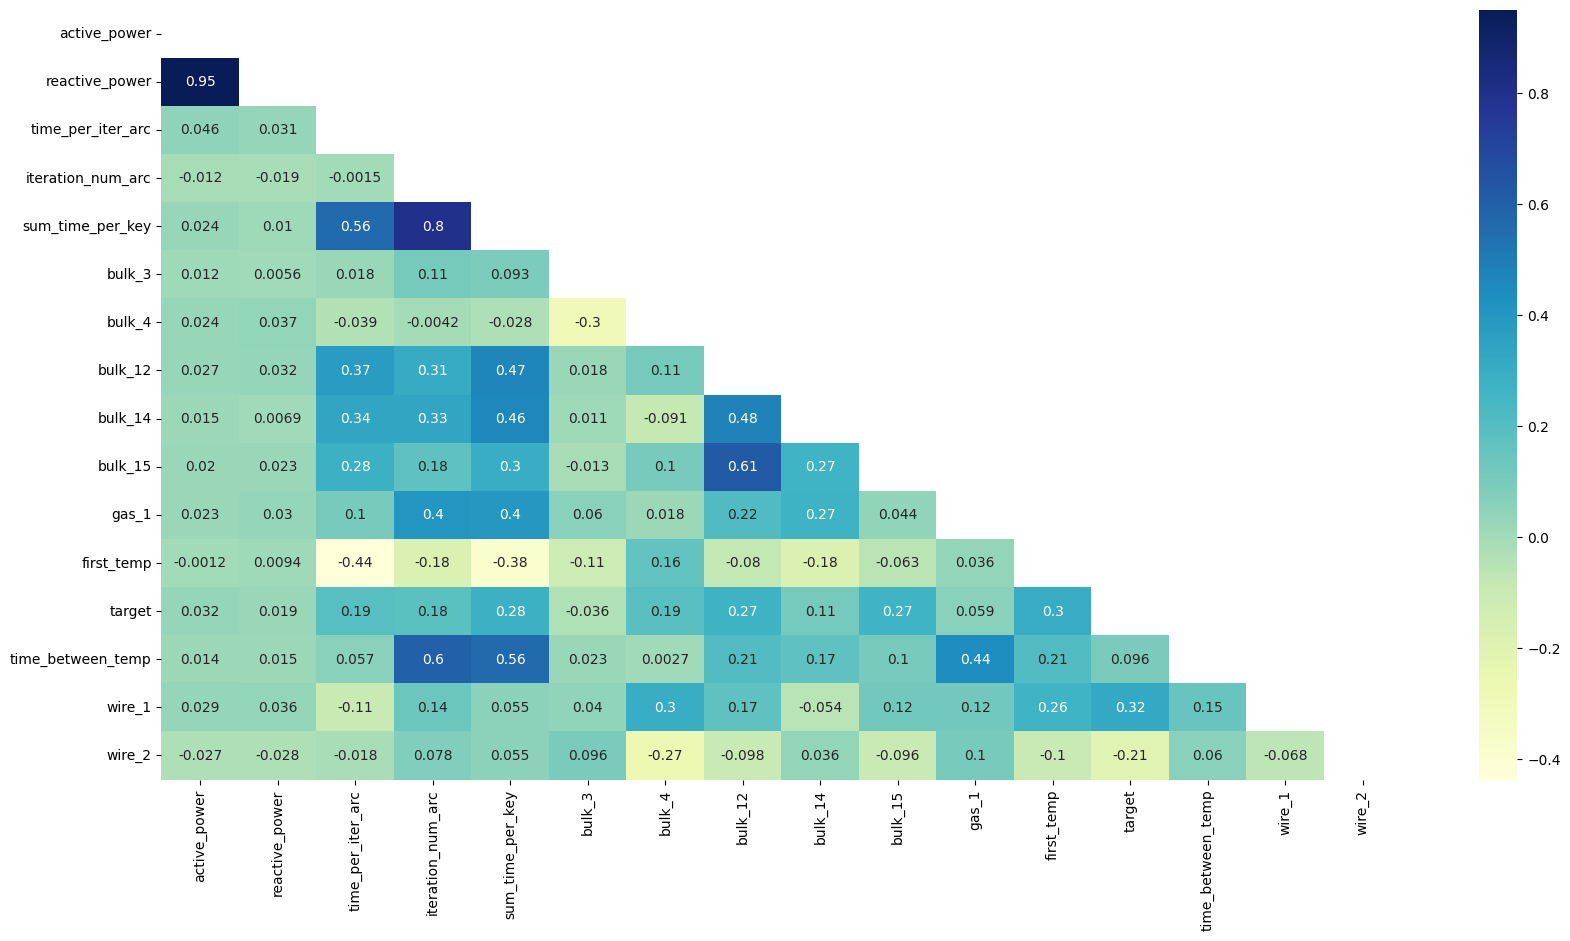

In [70]:
# Calculate the correlation matrix
corr = df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='YlGnBu', mask=mask, cbar=True)
plt.show()

- **Active vs. Reactive Power**: There is an extremely high correlation between `active_power` and `reactive_power` (0.95). Since `active_power` is more directly associated with energy consumption and process efficiency, we will drop `reactive_power` to resolve this multi-collinearity.
- **Heating Durations**: A high correlation is observed between `sum_time_per_key` and `iteration_num_arc` (0.8).
- **Moderate Correlations**: *
   - `time_between_temp` and `iteration_num_arc` (0.6)
   - `bulk_12` and `bulk_15` (0.61)
   - `sum_time_per_key` and `time_per_iter_arc` (0.56)

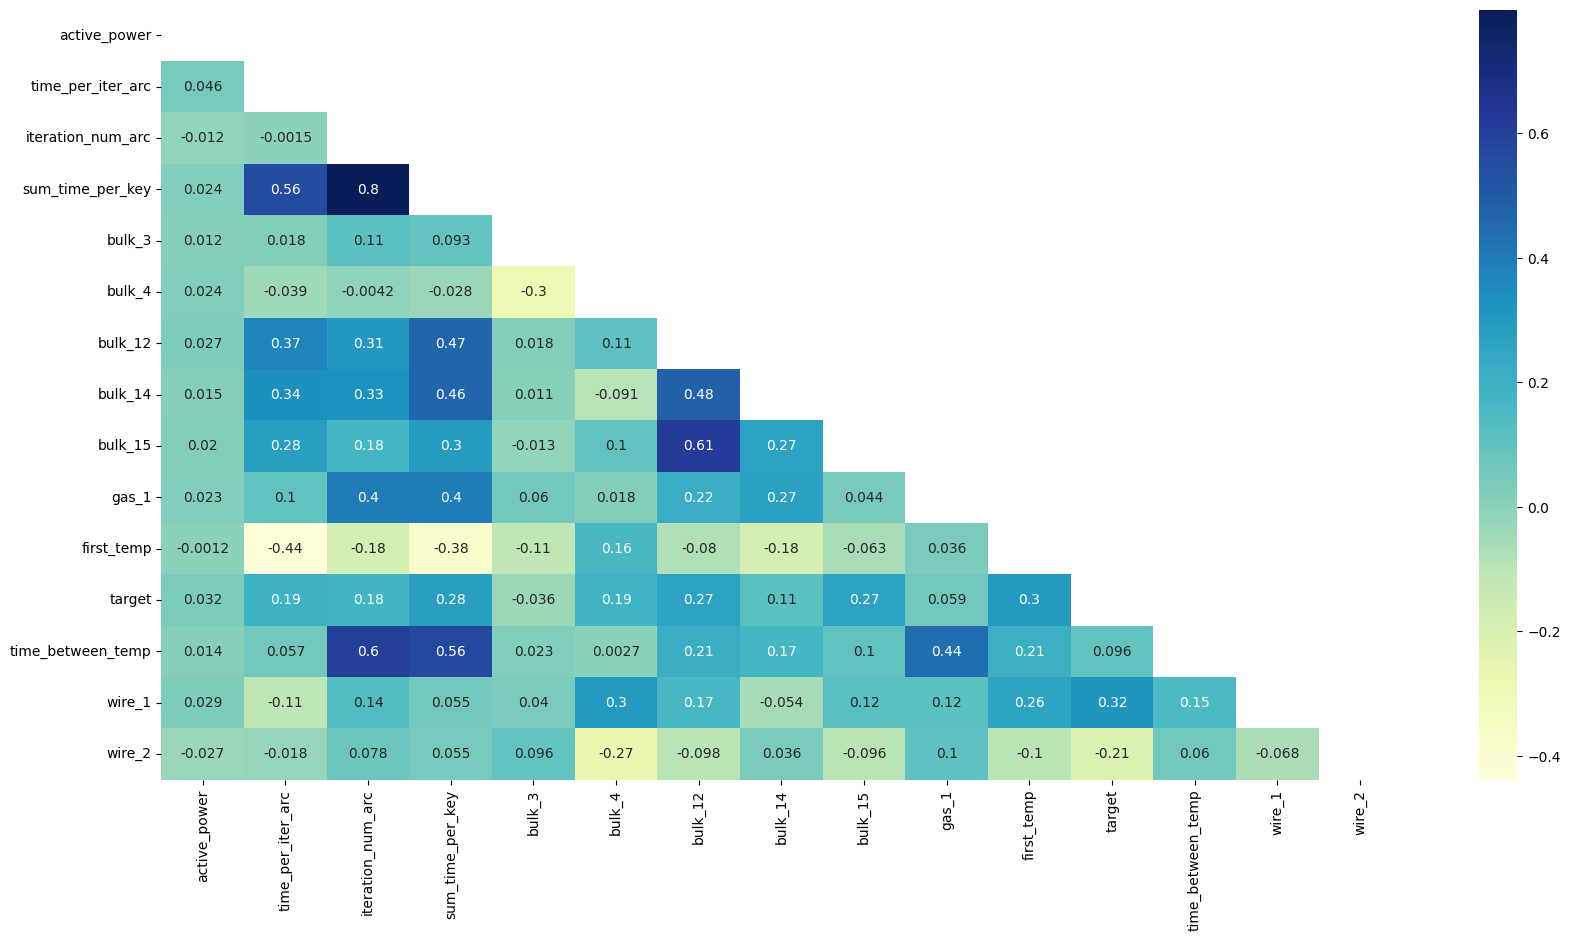

In [71]:
# Drop the reactive_power feature
df = df.drop('reactive_power', axis=1)

# Verify the changes by regenerating the correlation matrix
corr = df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the updated heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='YlGnBu', mask=mask, cbar=True)
plt.show()

The feature `reactive_power`, which had a critical correlation coefficient ($r \ge 0.9$), has been successfully removed.

## <a name='Modeling'></a> Data Preparation for Modeling

- We will now split the data into training and test sets.
- According to the customer's requirements, the training set must contain more than 1,700 records.

In [72]:
# Verify that missing values in bulk and wire columns were replaced with zeros
display((df[['bulk_3', 'bulk_4', 'bulk_12', 'bulk_14', 'bulk_15', 'wire_1', 'wire_2']] == 0).sum())

,0
bulk_3,1369
bulk_4,1517
bulk_12,517
bulk_14,261
bulk_15,630
wire_1,23
wire_2,1518


In [73]:
# Split the data into features (X) and target variable (y)
X = df.drop('target', axis=1)
y = df['target']

# Perform the train-test split (25% for testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

# Check the size of the training set
display(X_train.shape)

(1746, 14)

- The training set contains 1,746 rows, which meets the requirements (> 1,700).
- Gaps in the bulk and wire features were filled with zeros, and outliers were not removed—the data was only visualized using boxplots during the EDA stage.

## <a name='Training'></a> Model Training and Hyperparameter Tuning

### Linear Regression

In [74]:
# Pipeline for Linear Regression (scaling is mandatory for this model)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),   # Feature scaling
    ('lr', LinearRegression())      # Linear Regression model
])

# Cross-validation for Linear Regression using cross_val_score
cv_scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
mean_lr_score = -cv_scores_lr.mean()  # Average MAE for Linear Regression

print(f"Mean MAE for Linear Regression (cross-validation): {mean_lr_score:.4f}")

Mean MAE for Linear Regression (cross-validation): 6.2072


### RandomForest


In [75]:
model_rf = RandomForestRegressor(random_state=RANDOM_STATE)

# Hyperparameters for GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Cross-validation with GridSearchCV
grid_rf = GridSearchCV(model_rf, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

# Best result for Random Forest
best_rf_score = -grid_rf.best_score_
print(f"Best MAE for Random Forest: {best_rf_score:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best MAE for Random Forest: 6.3041


### LightGBM

In [76]:
model_gbm = LGBMRegressor(random_state=RANDOM_STATE)

# Hyperparameters for GridSearchCV
param_grid_lgb = {
    'num_leaves': [31, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200]
}

# Cross-validation with GridSearchCV
grid_lgb = GridSearchCV(model_gbm, param_grid_lgb, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
grid_lgb.fit(X_train, y_train)

# Best result for LightGBM
best_lgb_score = -grid_lgb.best_score_
print(f"Best LightGBM CV MAE: {best_lgb_score:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2597
[LightGBM] [Info] Number of data points in the train set: 1746, number of used features: 14
[LightGBM] [Info] Start training from score 1593.319015
Best LightGBM CV MAE: 6.1255


## <a name='Evaluation'></a> Model Evaluation and Selection

Based on the cross-validation results, LightGBM demonstrated the best performance with a $MAE$ of 6.1255.

In [77]:
# Best parameters for the LGBM model
best_params_lgb = grid_lgb.best_params_
print(f"Best parameters for LGBM: {best_params_lgb}")

# Apply the best model to the test set
y_pred = grid_lgb.best_estimator_.predict(X_test)

# Evaluate MAE on the test set
mae_test = mean_absolute_error(y_test, y_pred)
print(f"MAE on the test set: {mae_test:.4f}")

# Calculate the R2 metric
r2 = r2_score(y_test, y_pred)
print(f"R2 score on the test set: {r2:.4f}")

Best parameters for LGBM: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31}
MAE on the test set: 5.9420
R2 score on the test set: 0.3940


On the test set, the LightGBM model achieved a coefficient of determination $R^2 = 0.39$. This indicates that approximately 40% of the target variability is explained by the model, while the remaining 60% is likely due to noise, unrecorded parameters, or inherent process instability.

In [78]:
# Evaluate DummyRegressor on the test set
dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor.fit(X_train, y_train)
y_pred_dummy = dummy_regressor.predict(X_test)

# Baseline MAE
mae_test_dummy = mean_absolute_error(y_test, y_pred_dummy)
print(f"MAE on the test set for DummyRegressor: {mae_test_dummy:.4f}")

MAE on the test set for DummyRegressor: 7.4321


The LightGBM model ($MAE = 5.94$) significantly outperformed the baseline model ($MAE = 7.43$), successfully meeting the project's requirement of $MAE \le 6$.

## <a name='Importance'></a> Feature Importance Analysis

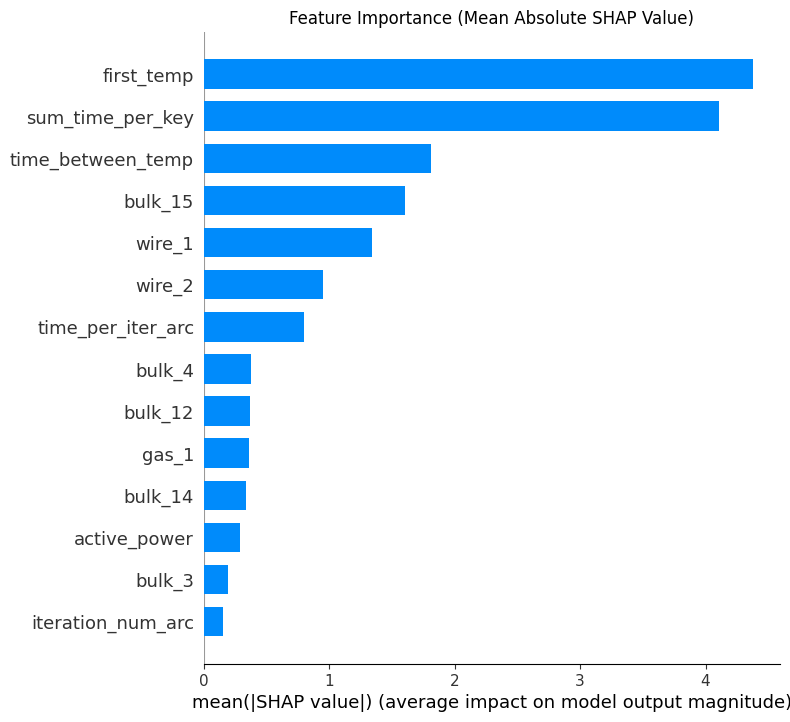

In [79]:
# Create the explainer and calculate SHAP values for the test set
explainer = shap.TreeExplainer(grid_lgb.best_estimator_)
shap_values = explainer.shap_values(X_test)

# Feature Importance Plot (Bar Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Feature Importance (Mean Absolute SHAP Value)')
plt.show()

**The leading features** by importance are:
- `first_temp`: The initial temperature measurement.
- `sum_time_per_key`: The total duration of arc heating for a single batch.

**Features with moderate influence** include:
- `time_between_temp`: The time elapsed between the first and last measurements.
- `bulk_15`: Volume of bulk material 15 added.
- `wire_1`: Volume of wire material 1 added.

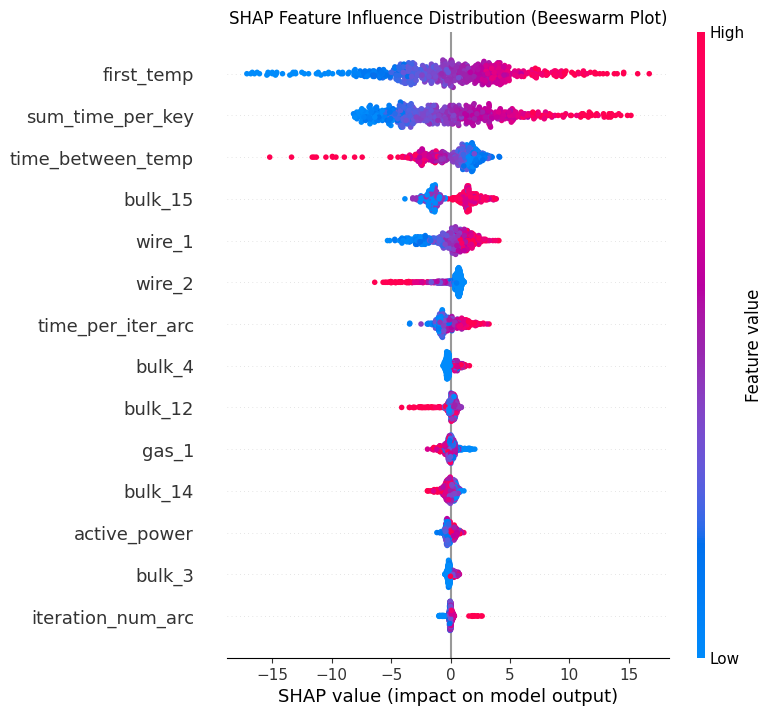

In [80]:
# Distribution of feature influence (Beeswarm Plot)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title('SHAP Feature Influence Distribution (Beeswarm Plot)')
plt.show()

- `first_temp` is the most significant factor: a low initial temperature consistently lowers the final temperature prediction, while a high initial temperature increases it. The magnitude of this effect varies significantly across different batches (indicated by the wide SHAP cloud).

- `sum_time_per_key` (total heating time) also exerts a major influence: longer heating periods lead to a higher predicted temperature, while shorter periods lead to a lower one. The variability of this influence is slightly lower than that of first_temp.

- `time_between_temp` (time between measurements) has a noticeable impact; specifically, an increase in this duration tends to decrease the predicted final temperature, likely due to heat loss over time.

- `bulk_15` shows a very stable but relatively weak influence on the final temperature (indicated by the narrow SHAP cloud).

- `wire_1` exhibits stable influence (medium-sized cloud). The addition of higher quantities of wire_1 tends to decrease the predicted final temperature, which may be related to the cooling effect of adding cold material into the melt.

## <a name='Recommendations'></a> Conclusions and Recommendations

As part of the project for the "Steel Bird" metallurgical plant, a machine learning model was developed to predict the final temperature of steel after the ladle furnace processing stage. The project involved cleaning, aggregating, and merging seven disparate data sources, during which anomalies and missing values were identified and addressed. The final dataset included key features reflecting heating parameters, material additions, and temperature measurement timings.

**Model Performance Summary**
The best performance was achieved using the LightGBM model:
- MAE (Test Set): 5.94 (meets the target of $MAE \le 6$)
- $R^2$ (Test Set): 0.39
   - It indicates that the model explains nearly 40% of the variance in the final steel temperature based on the available data. The remaining 60% of the variance is attributed to process noise, inherent instability, or external parameters not captured in the current datasets.
- Baseline Comparison: Significantly outperforms the DummyRegressor ($MAE = 7.43$).

**Best Hyperparameters for LightGBM**:
- learning_rate: 0.05
- n_estimators: 100
- num_leaves: 31
- random_state: 70425

**Feature Importance and SHAP Analysis**

The SHAP method allowed us to identify not only the most influential factors but also the nature of their impact on the final temperature prediction:

**Primary Drivers**:
- `first_temp` (Initial Temperature): The most critical factor. Lower initial values consistently decrease the final prediction, while higher values increase it. The impact strength varies significantly from batch to batch.
- `sum_time_per_key` (Total Heating Duration): The second most important feature. Increased heating time leads to higher predicted temperatures, with less variability in its impact compared to the initial temperature.

**Secondary Influences**:
- `time_between_temp` (Time Between Measurements): Increasing this interval tends to decrease the final temperature prediction (likely due to cooling/heat loss).
- `bulk_15` and `wire_1` (Materials): These show a stable but relatively weak influence on the outcome.
- `wire_2` (Wire Material): Shows a stable influence; its addition generally results in a decrease in the predicted final temperature.

**Business Recommendations**
1. Model Deployment: We recommend integrating the trained LightGBM model into the production cycle as a Decision Support System (DSS) to forecast final temperatures and optimize energy consumption.
2. Focus on Key Drivers: Management should prioritize the control of initial temperature and total heating time, as these are the primary levers for achieving the target temperature.
3. Process Awareness: When planning production, account for the cooling effect of the time gap between measurements and the addition of specific materials like wire_1 and wire_2.
4. Scenario Modeling: Utilize the model for "What-if" analysis to simulate various heating regimes and additive combinations to find the most cost-effective path to the target temperature.
5. Data Quality Strategy: Continue collecting high-resolution data on additives and gas purging. Improving data quality for features currently showing weak influence may enhance model accuracy in future iterations.
6. Continuous Monitoring: Establish a feedback loop to monitor model performance on live data and periodically retrain the model to adapt to shifts in the technological process.

In [81]:
# Calculate total execution time
end_time = time.time()
execution_time = (end_time - start_time) / 60  # convert to minutes

print(f"Total execution time: {execution_time:.2f} minutes")

Total execution time: 5.55 minutes
